In [1]:
from data import load_mri_dataframe, get_dataloaders
from sklearn.model_selection import train_test_split

In [2]:
df = load_mri_dataframe()
#df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=42, stratify=df["diagnosis"])
#df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=48, stratify=df["diagnosis"])
#train_loader, val_loader = get_dataloaders(df, omit_empty_masks=True, augment=True)

In [3]:
import torch
import torch.nn as nn

In [4]:
class BaselineUNet0(nn.Module):
    def __init__(self):
        super().__init__()
        num_classes = 1
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)  # 128x128

        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)  # 64x64

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

        # Decoder
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)  # 64x64
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # 128x128
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())

        # Final
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.final(d1)


[I 2025-06-23 23:21:01,617] A new study created in memory with name: no-name-15dba64e-473b-4ca1-872c-f88881733939


[Data] Train images: 778 ; Val images: 389


Stopped early at epoch 20!
[Data] Train images: 778 ; Val images: 389


Stopped early at epoch 21!
[Data] Train images: 778 ; Val images: 389


[I 2025-06-23 23:24:14,802] Trial 0 finished with value: 0.5167765023135845 and parameters: {'lr': 0.0023314250570087174, 'batch_size': 4, 'optimizer': 'Adam', 'num_layers': 2, 'num_filters': 8, 'step_size': 6, 'gamma': 0.15553008562695078}. Best is trial 0 with value: 0.5167765023135845.


...

Stopped early at epoch 10!
[Data] Train images: 778 ; Val images: 389


Stopped early at epoch 43!
[Data] Train images: 778 ; Val images: 389


Stopped early at epoch 10!
[Data] Train images: 778 ; Val images: 389


[I 2025-06-24 05:27:09,224] Trial 29 finished with value: 0.7756430399255687 and parameters: {'lr': 0.00012604953944096237, 'batch_size': 4, 'optimizer': 'Adam', 'num_layers': 4, 'num_filters': 32, 'step_size': 7, 'gamma': 0.4660781817469907}. Best is trial 25 with value: 0.7894523648583158.


Stopped early at epoch 23!
Best trial without augmentation: 25 with value 0.7894523648583158
[Data] Train images: 1167 ; Val images: 206


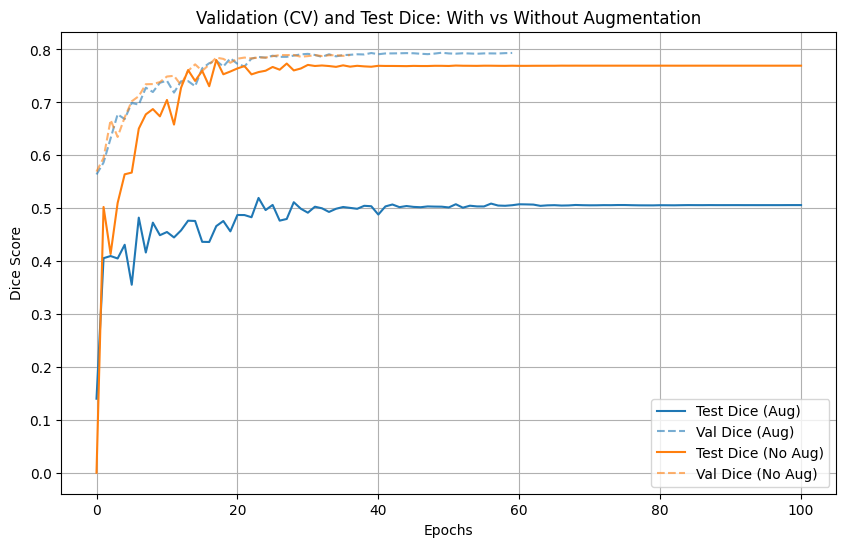

In [ ]:
from train_generalized_earlystopping import train, dice_loss, bce_loss, bce_dice_loss, tversky_loss
from eval import evaluate, evaluate_losses, evaluate_classification
from hyperparameter_search import create_study
from BaselineUNetParams import BaselineUNet
from OriginalUNet import OriginalUNet
import torch.optim as optim
# Compare model with and without augmentation: plot val (CV) and test dice for both

# 1. Run hyperparameter search and training WITH augmentation
study_aug = create_study(n_trials=30, df=df, augment=True)
params_aug = study_aug.best_params
trial_aug = study_aug.best_trial
print(f"Best trial with augmentation: {trial_aug.number} with value {trial_aug.value}")
train_loader_aug, val_loader_aug = get_dataloaders(df, val_split=0.15, batch_size=params_aug["batch_size"], omit_empty_masks=True, augment=True)

model_aug = BaselineUNet(num_layers=params_aug['num_layers'], num_filters=params_aug['num_filters'])
device = torch.device('cuda')
trained_model_aug, results_aug = train(
    model_aug,
    train_loader_aug,
    val_loader_aug,
    device,
    lr=params_aug['lr'],
    optimizer_class=optim.Adam if params_aug['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_aug['step_size'], "gamma": params_aug['gamma']},
    early_stopping=False
)

cv_val_dice_aug = study_aug.best_trial.user_attrs.get("cv_val_dice", None)
if cv_val_dice_aug is not None:
    results_aug["history"]["cv_val_dice"] = cv_val_dice_aug

device = torch.device('cuda')

# 2. Run hyperparameter search and training WITHOUT augmentation
study_noaug = create_study(n_trials=30, df=df, augment=False)
params_noaug = study_noaug.best_params
trial_noaug = study_noaug.best_trial
print(f"Best trial without augmentation: {trial_noaug.number} with value {trial_noaug.value}")

train_loader_noaug, val_loader_noaug = get_dataloaders(df, val_split=0.15, batch_size=params_aug["batch_size"], omit_empty_masks=True, augment=False)

model_noaug = BaselineUNet(num_layers=params_noaug['num_layers'], num_filters=params_noaug['num_filters'])
trained_model_noaug, results_noaug = train(
    model_noaug,
    train_loader_noaug,
    val_loader_noaug,
    device,
    lr=params_noaug['lr'],
    optimizer_class=optim.Adam if params_noaug['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug['step_size'], "gamma": params_noaug['gamma']},
    early_stopping=False
)

cv_val_dice_noaug = study_noaug.best_trial.user_attrs.get("cv_val_dice", None)
if cv_val_dice_noaug is not None:
    results_noaug["history"]["cv_val_dice"] = cv_val_dice_noaug

# 3. Plot both val (CV) and test dice for both models
import matplotlib.pyplot as plt

epochs_aug = range(len(results_aug["history"]["val_dice"]))
epochs_noaug = range(len(results_noaug["history"]["val_dice"]))

plt.figure(figsize=(10, 6))
plt.plot(epochs_aug, results_aug["history"]["val_dice"], label="Test Dice (Aug)", color="tab:blue")
if "cv_val_dice" in results_aug["history"]:
    min_len = min(len(epochs_aug), len(results_aug["history"]["cv_val_dice"]))
    plt.plot(
        list(epochs_aug)[:min_len],
        results_aug["history"]["cv_val_dice"][:min_len],
        "--", label="Val Dice (Aug)", color="tab:blue", alpha=0.6
    )

plt.plot(epochs_noaug, results_noaug["history"]["val_dice"], label="Test Dice (No Aug)", color="tab:orange")
if "cv_val_dice" in results_noaug["history"]:
    min_len = min(len(epochs_noaug), len(results_noaug["history"]["cv_val_dice"]))
    plt.plot(
        list(epochs_noaug)[:min_len],
        results_noaug["history"]["cv_val_dice"][:min_len],
        "--", label="Val Dice (No Aug)", color="tab:orange", alpha=0.6
    )

plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.title("Validation (CV) and Test Dice: With vs Without Augmentation")
plt.legend()
plt.grid(True)
plt.show()

Final Test Dice: 0.5059
Final Test IoU : 0.4145


ValueError: x and y must have same first dimension, but have shapes (101,) and (60,)

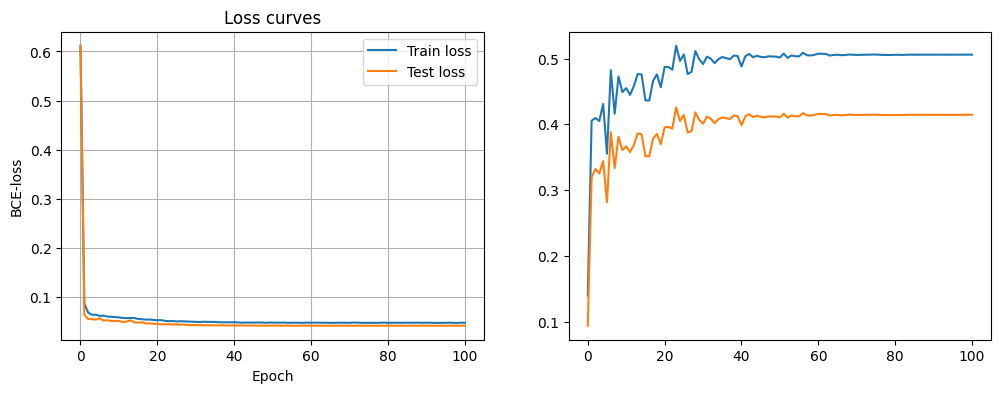

In [6]:
evaluate(results_aug)

Final Test Dice: 0.7694
Final Test IoU : 0.6850


ValueError: x and y must have same first dimension, but have shapes (101,) and (37,)

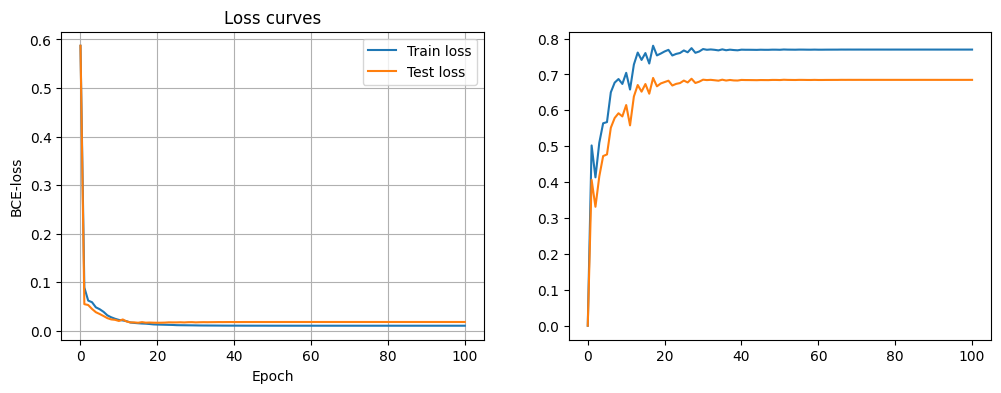

In [7]:
evaluate(results_noaug)

Final Test Dice: 0.6969
Final Test IoU : 0.6122


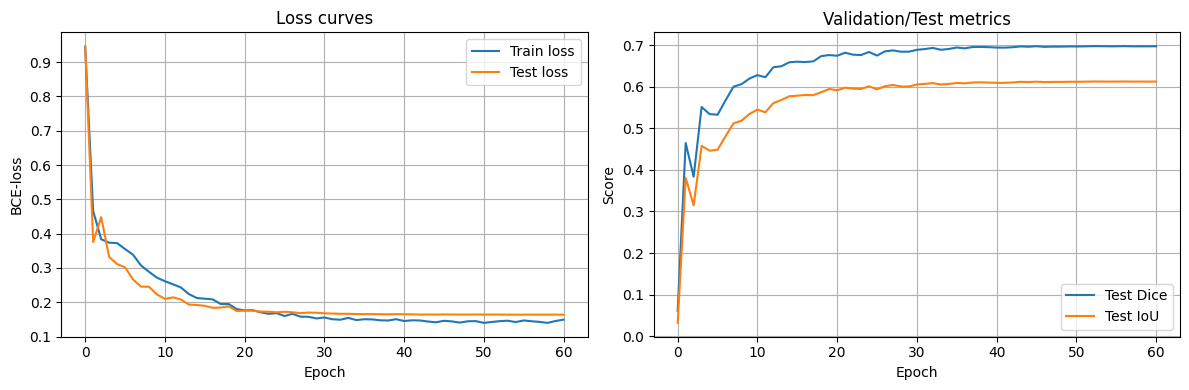

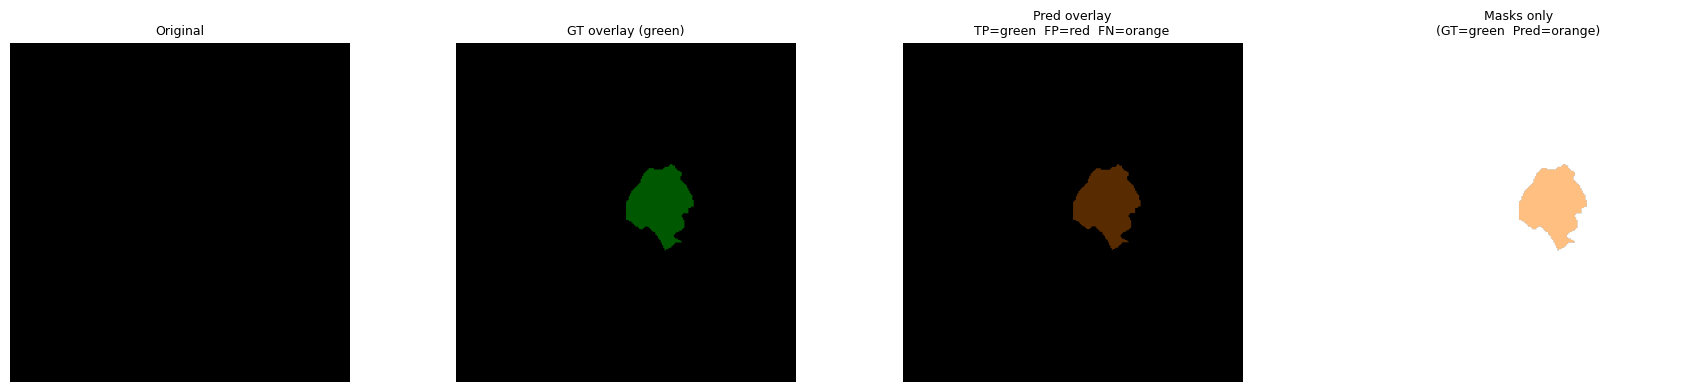

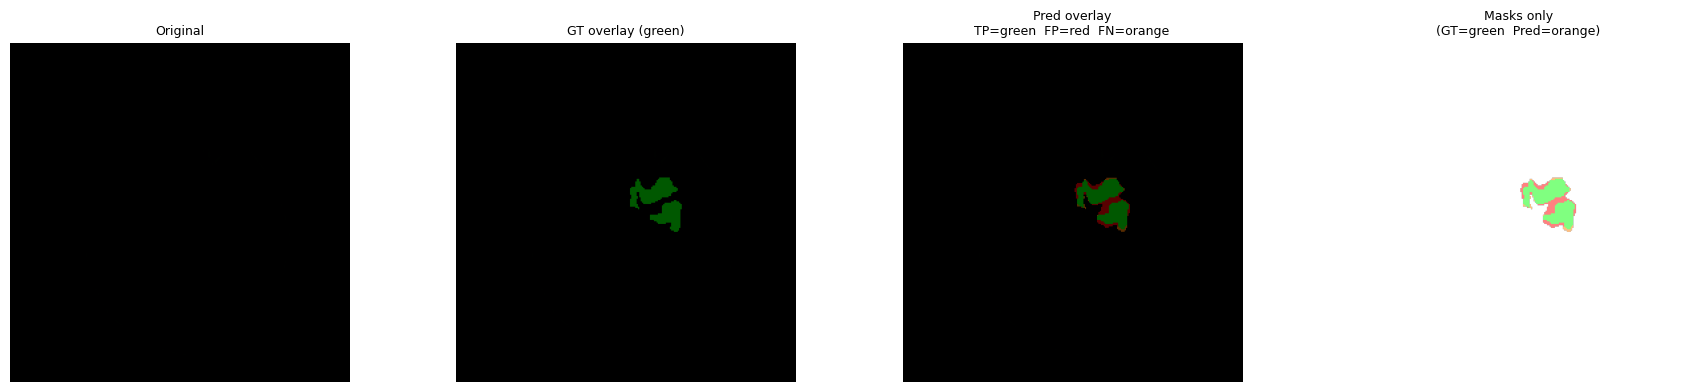

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


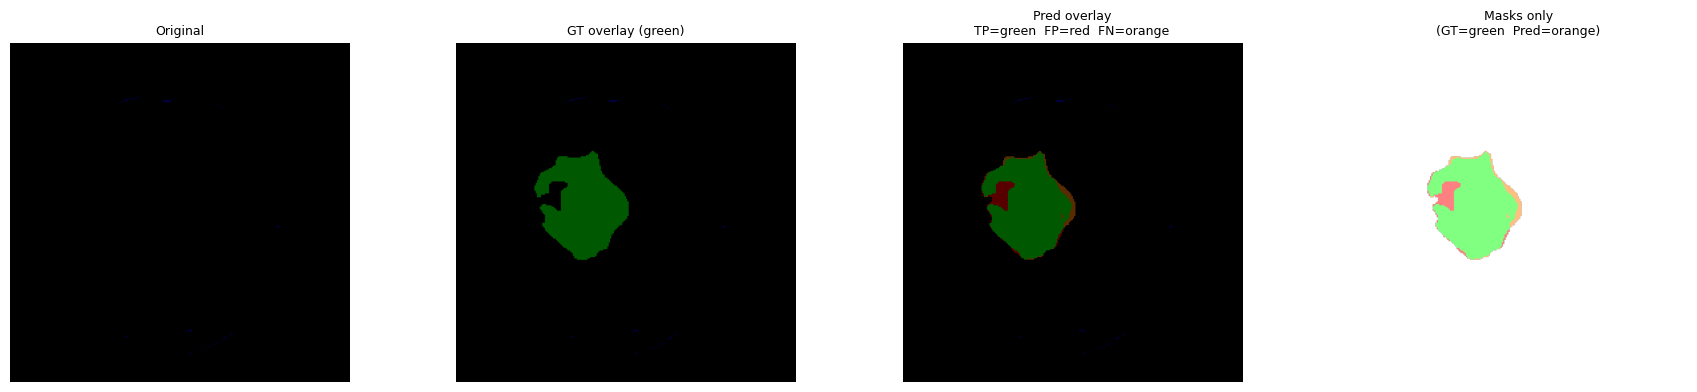

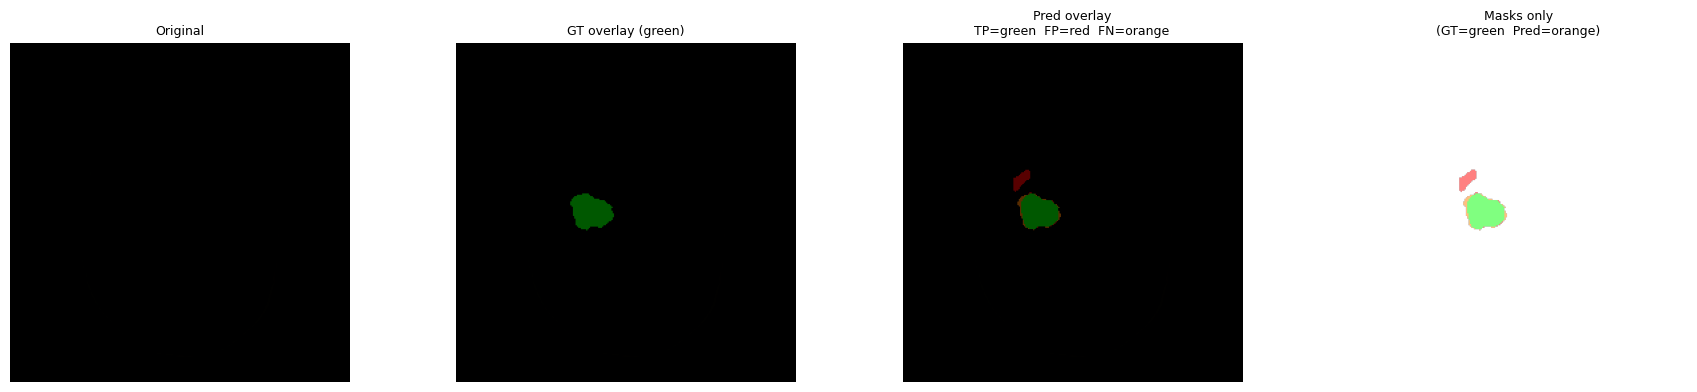

In [25]:
model = BaselineUNet(num_layers=params_noaug['num_layers'], num_filters=params_noaug['num_filters'])
device = torch.device('cuda')

trained_model, results_dice_noaug = train(
        model,
        train_loader_noaug,
        val_loader_noaug,
        device,
        lr=params_noaug['lr'],
        optimizer_class=optim.Adam if params_noaug['optimizer'] == "Adam" else optim.SGD,
        loss_fn=dice_loss,
        epochs=60,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params_noaug['step_size'], "gamma": params_noaug['gamma']},
        early_stopping=False
    )

evaluate(results_dice_noaug)

Final Test Dice: 0.7625
Final Test IoU : 0.6751


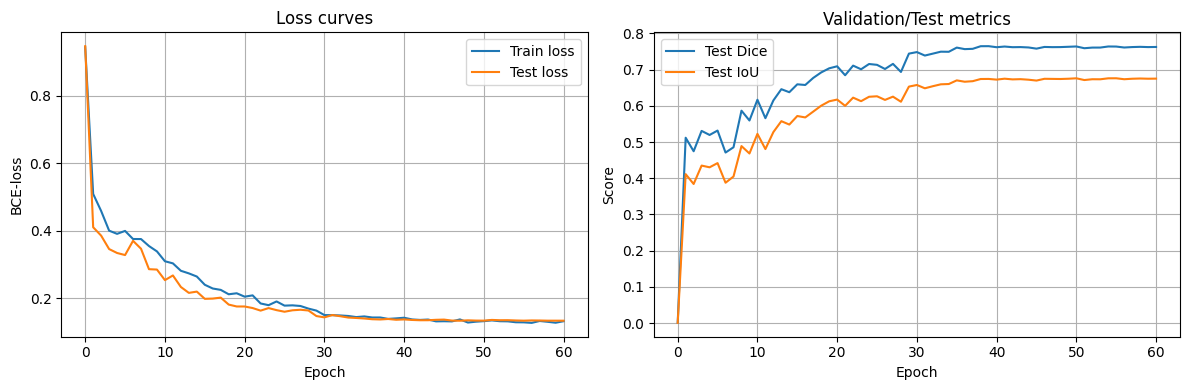

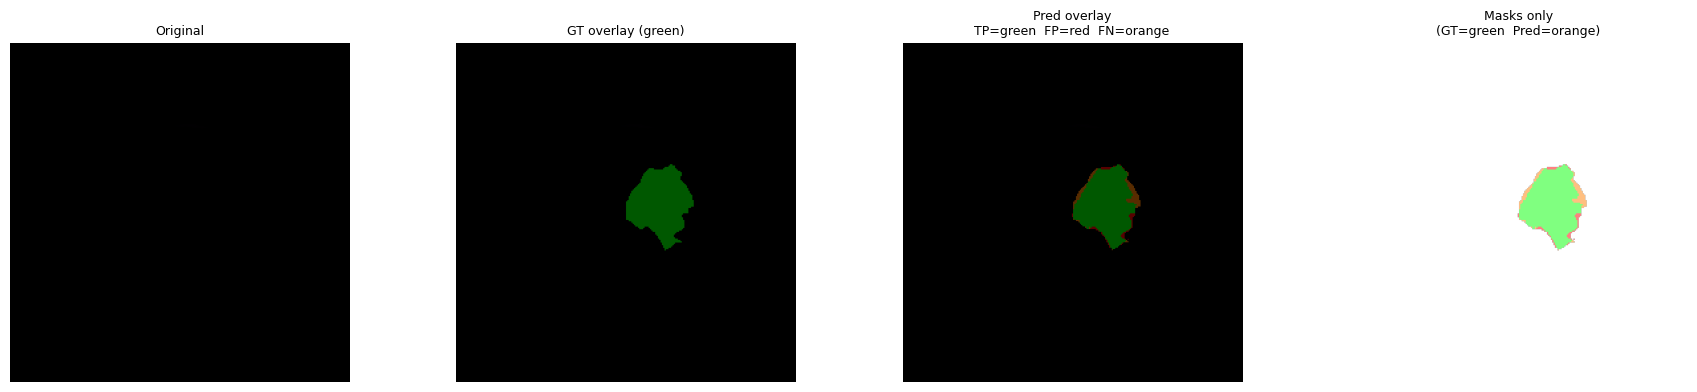

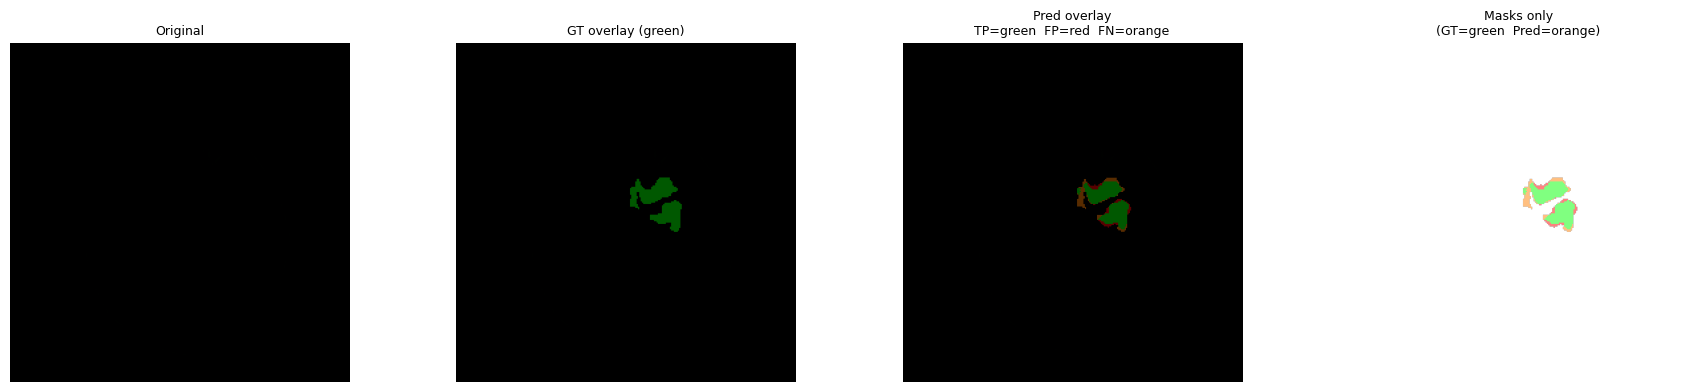

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


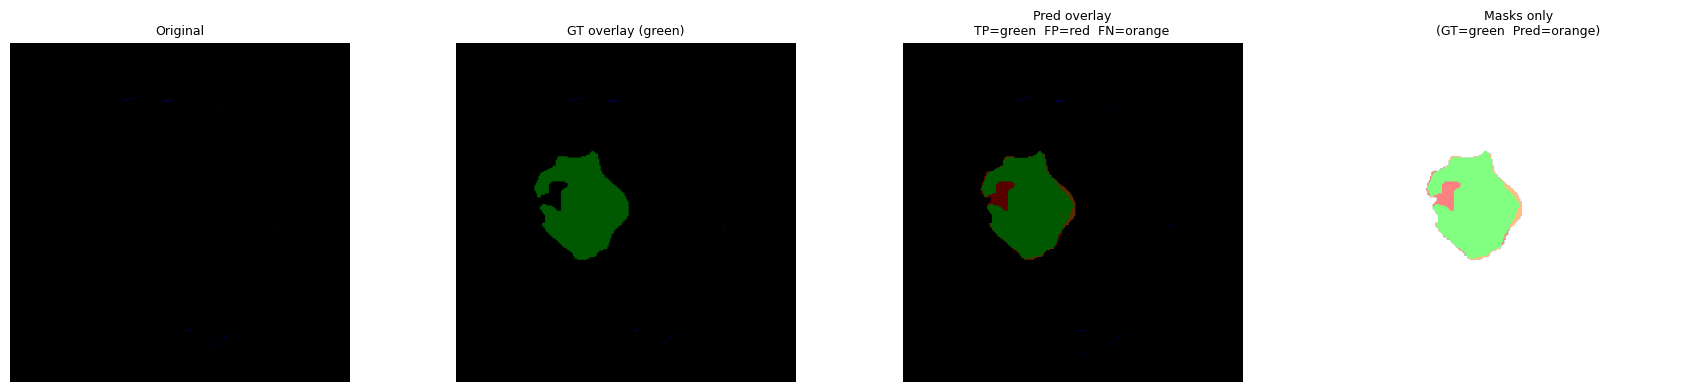

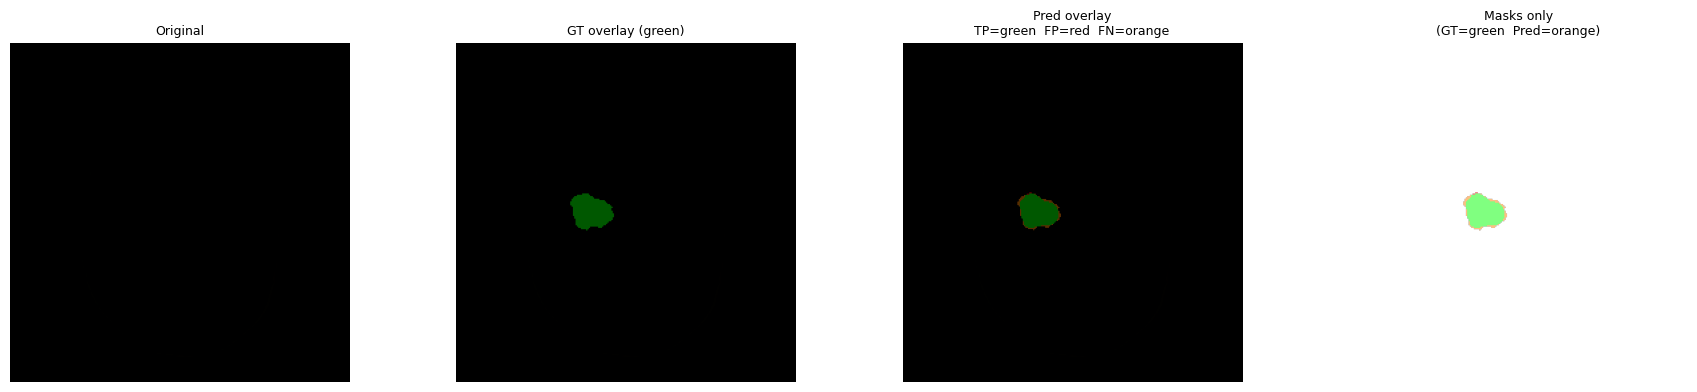

In [10]:
model = BaselineUNet(num_layers=params_aug['num_layers'], num_filters=params_aug['num_filters'])
device = torch.device('cuda')

trained_model, results_dice_aug = train(
        model,
        train_loader_aug,
        val_loader_aug,
        device,
        lr=params_aug['lr'],
        optimizer_class=optim.Adam if params_aug['optimizer'] == "Adam" else optim.SGD,
        loss_fn=dice_loss,
        epochs=60,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params_aug['step_size'], "gamma": params_aug['gamma']},
        early_stopping=False
    )   

evaluate(results_dice_aug)

Final Test Dice: 0.7876
Final Test IoU : 0.6988


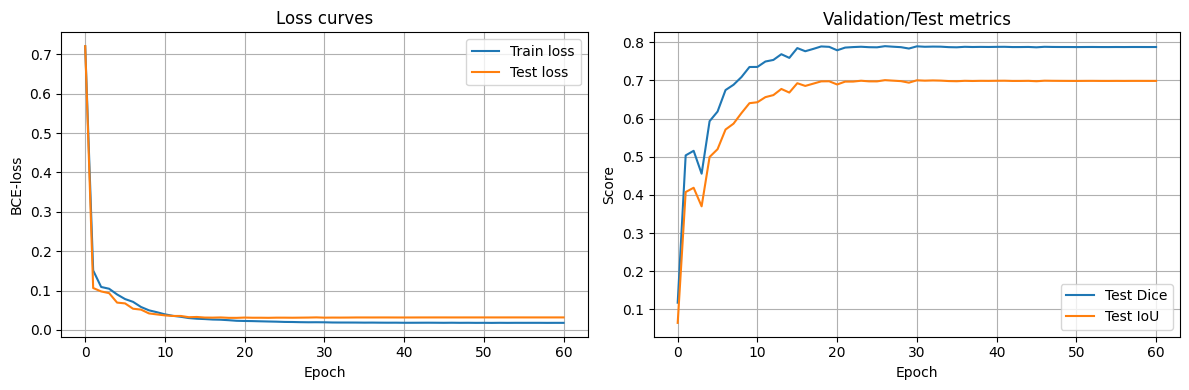

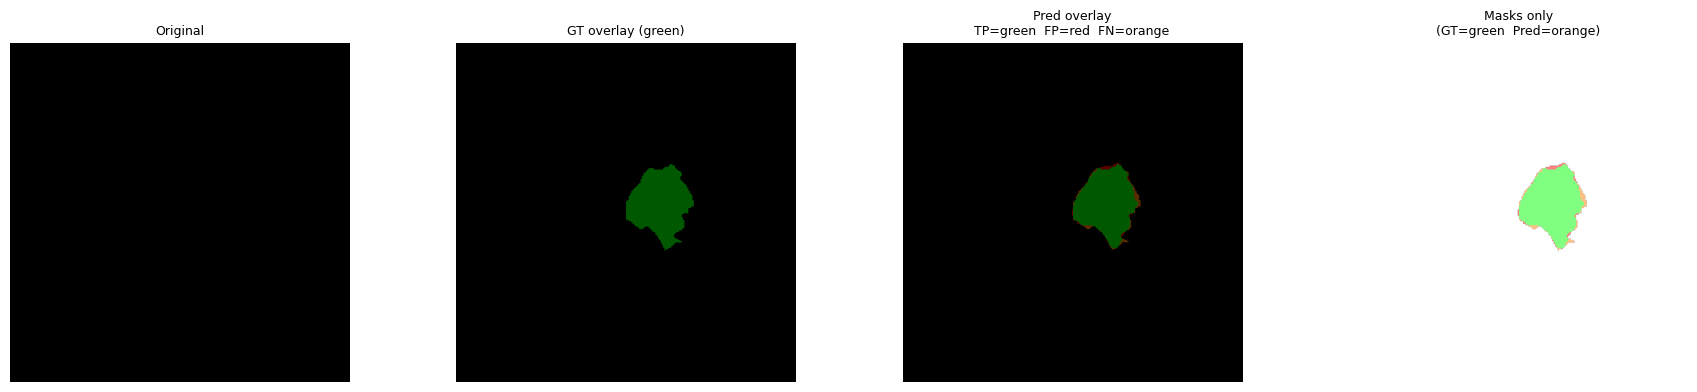

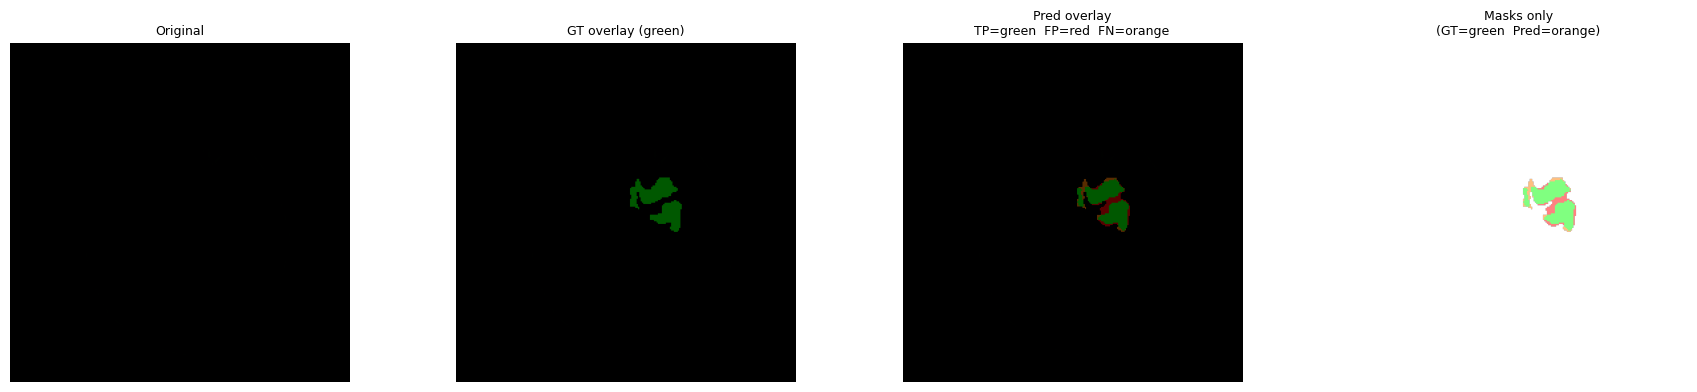

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


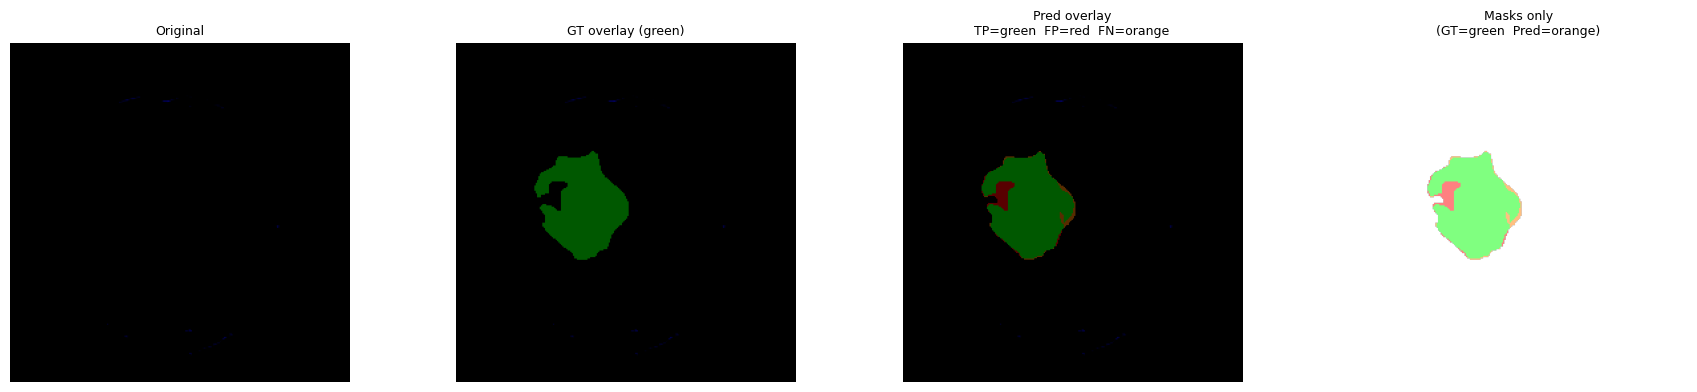

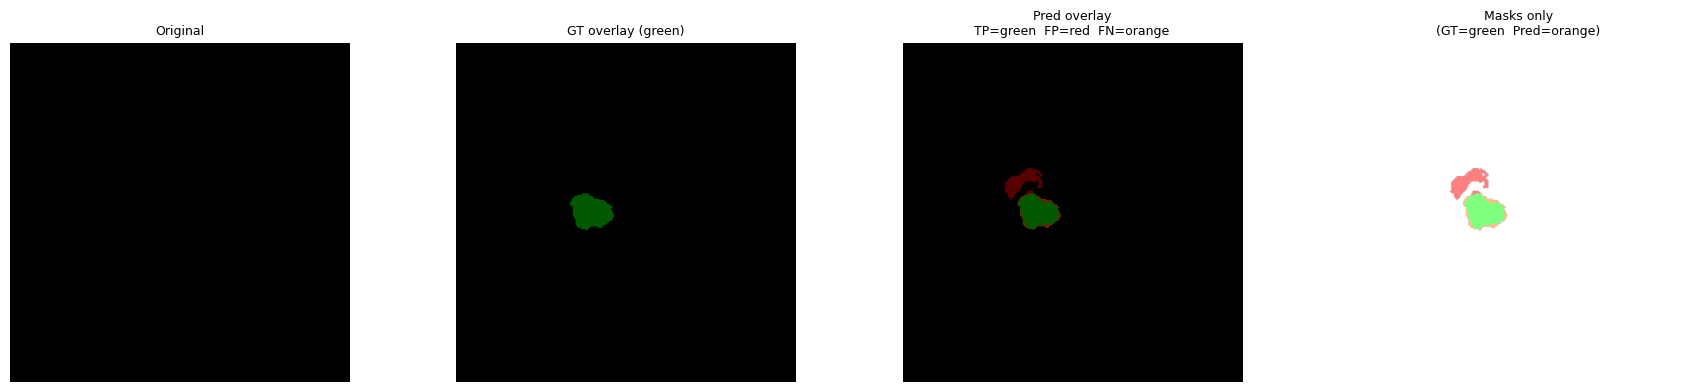

In [11]:
model = BaselineUNet(num_layers=params_noaug['num_layers'], num_filters=params_noaug['num_filters'])
device = torch.device('cuda')

trained_model, results_bce_dice_noaug = train(
        model,
        train_loader_noaug,
        val_loader_noaug,
        device,
        lr=params_noaug['lr'],
        optimizer_class=optim.Adam if params_noaug['optimizer'] == "Adam" else optim.SGD,
        loss_fn=bce_dice_loss,
        epochs=60,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params_noaug['step_size'], "gamma": params_noaug['gamma']},
        early_stopping=False
    )

evaluate(results_bce_dice_noaug)

Final Test Dice: 0.7676
Final Test IoU : 0.6775


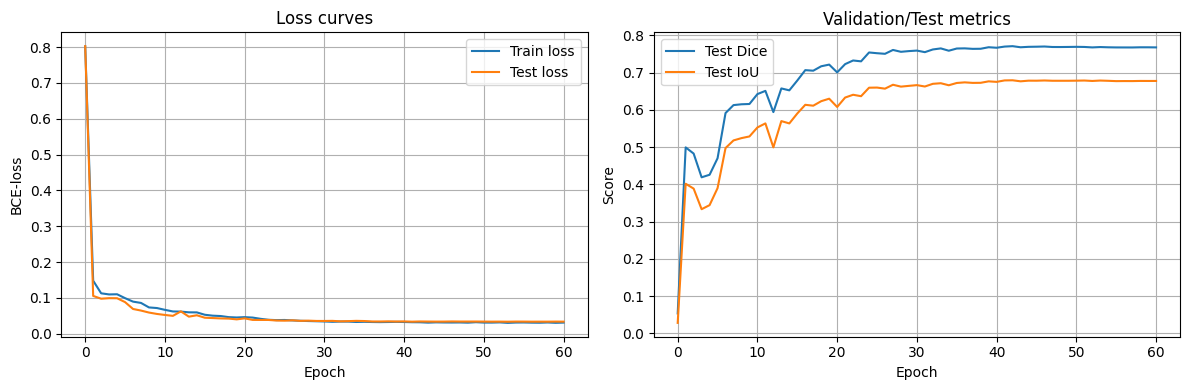

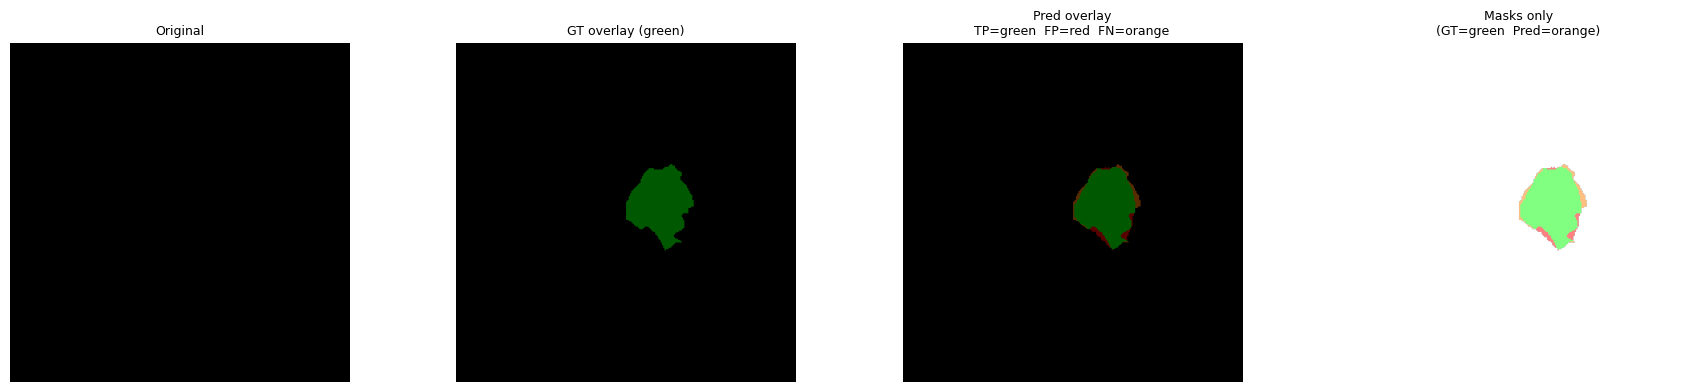

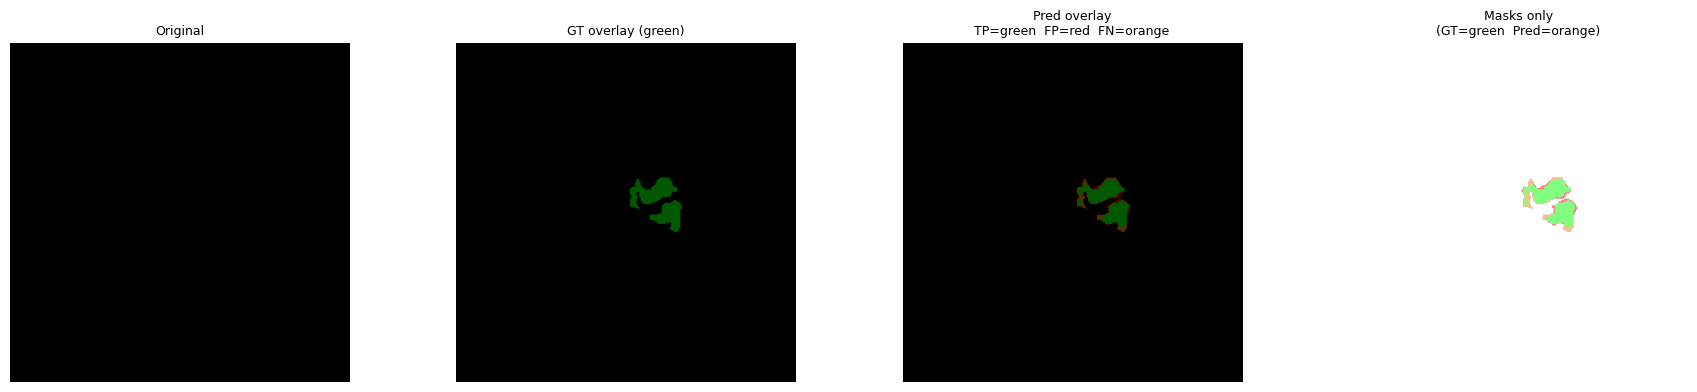

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


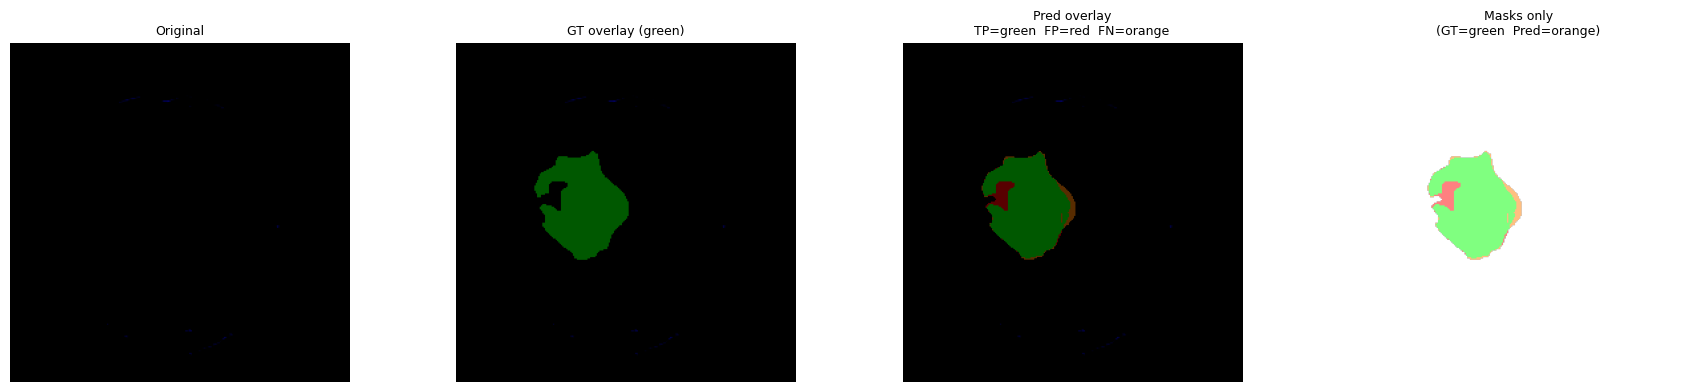

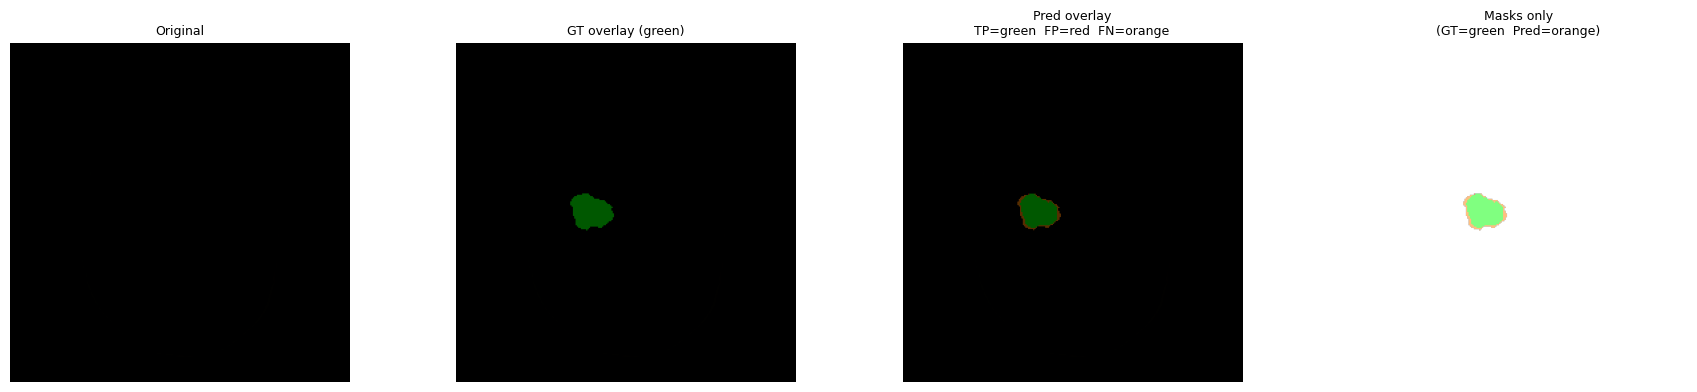

In [12]:
model = BaselineUNet(num_layers=params_aug['num_layers'], num_filters=params_aug['num_filters'])
device = torch.device('cuda')

trained_model, results_bce_dice_aug = train(
        model,
        train_loader_aug,
        val_loader_aug,
        device,
        lr=params_aug['lr'],
        optimizer_class=optim.Adam if params_aug['optimizer'] == "Adam" else optim.SGD,
        loss_fn=bce_dice_loss,
        epochs=60,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params_aug['step_size'], "gamma": params_aug['gamma']},
        early_stopping=False
    )   

evaluate(results_bce_dice_aug)

Final Test Dice: 0.7238
Final Test IoU : 0.6380


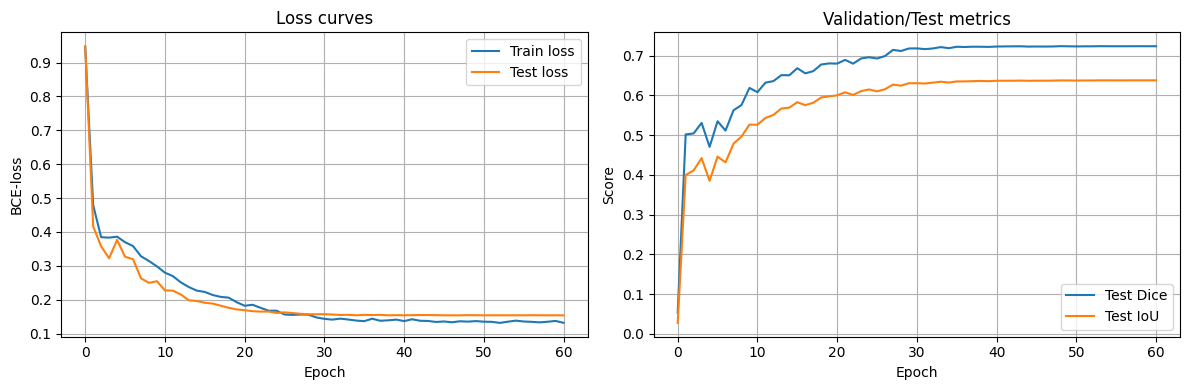

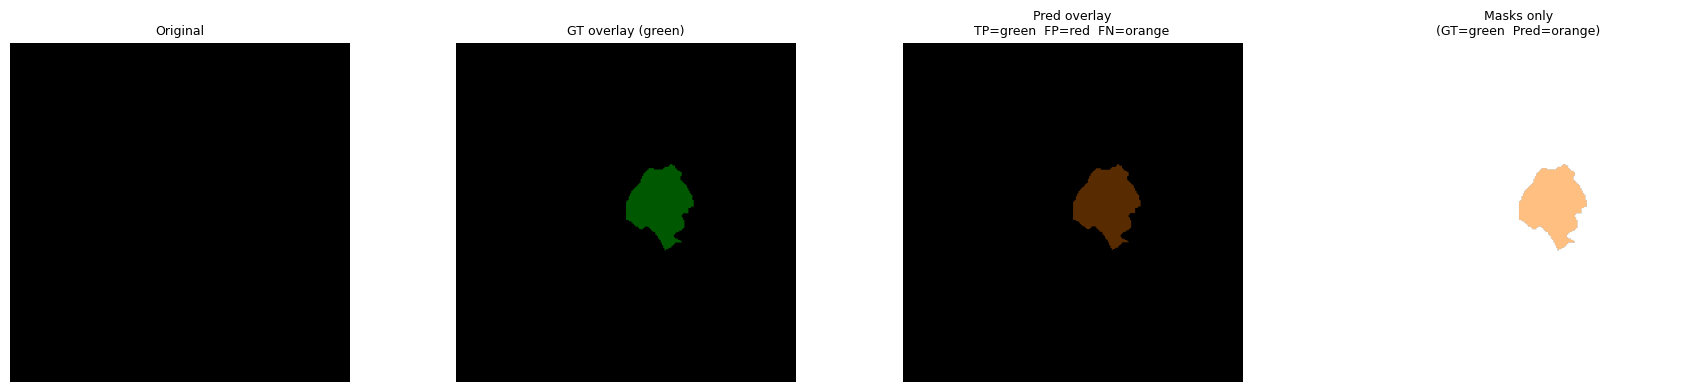

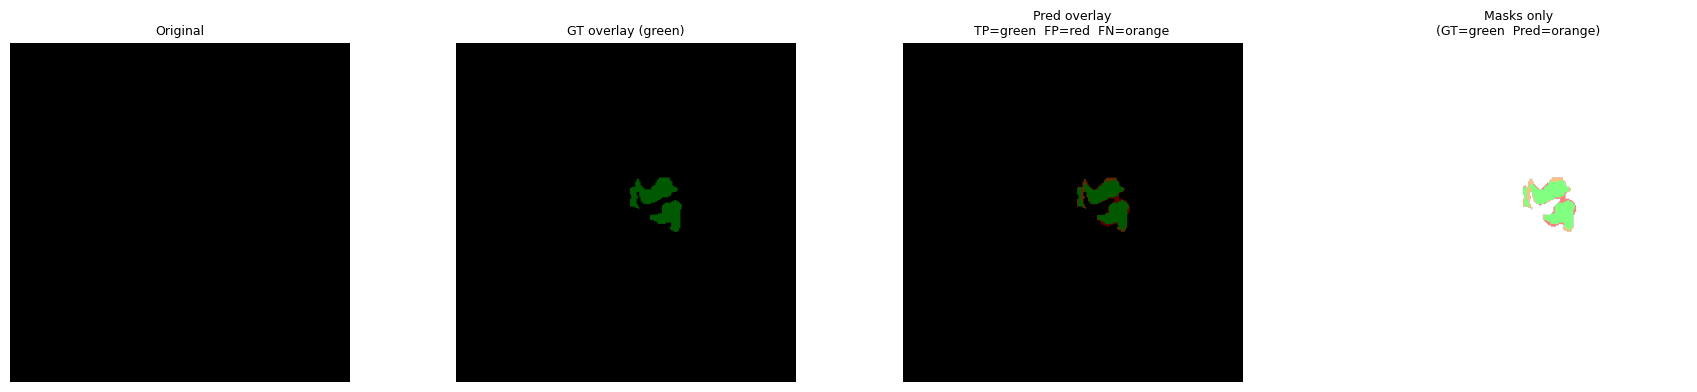

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


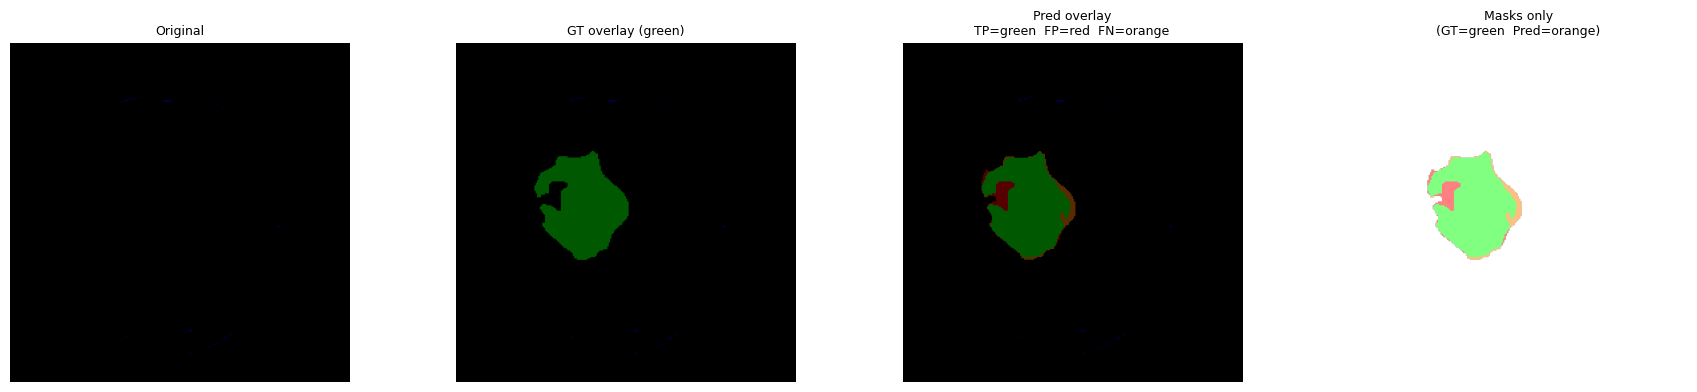

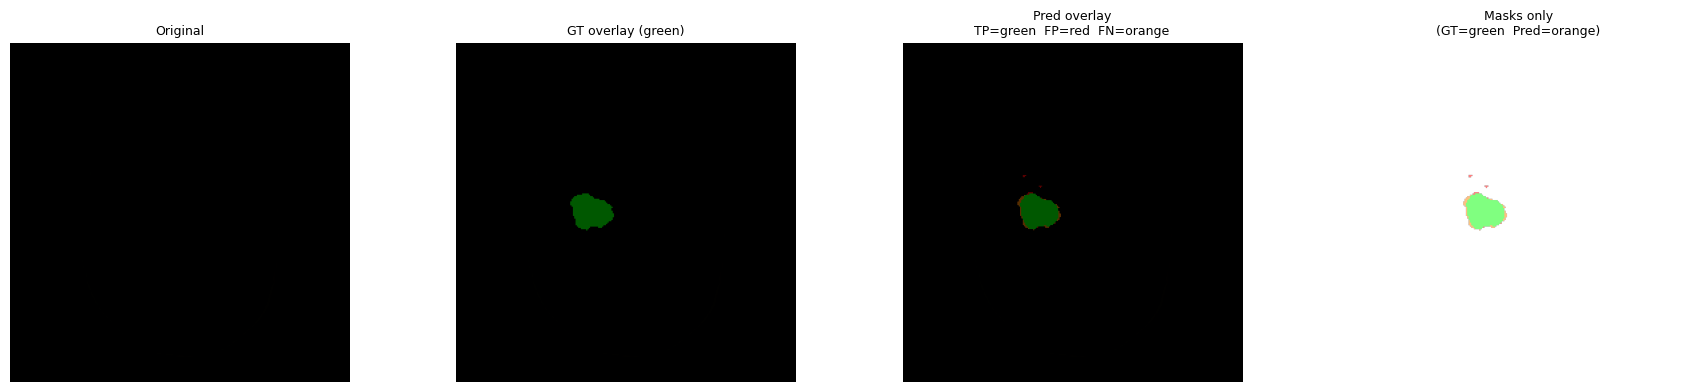

In [13]:
model = BaselineUNet(num_layers=params_noaug['num_layers'], num_filters=params_noaug['num_filters'])
device = torch.device('cuda')

trained_model, results_tversky_noaug = train(
        model,
        train_loader_noaug,
        val_loader_noaug,
        device,
        lr=params_noaug['lr'],
        optimizer_class=optim.Adam if params_noaug['optimizer'] == "Adam" else optim.SGD,
        loss_fn=tversky_loss,
        epochs=60,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params_noaug['step_size'], "gamma": params_noaug['gamma']},
        early_stopping=False
    )

evaluate(results_tversky_noaug)

Final Test Dice: 0.7304
Final Test IoU : 0.6469


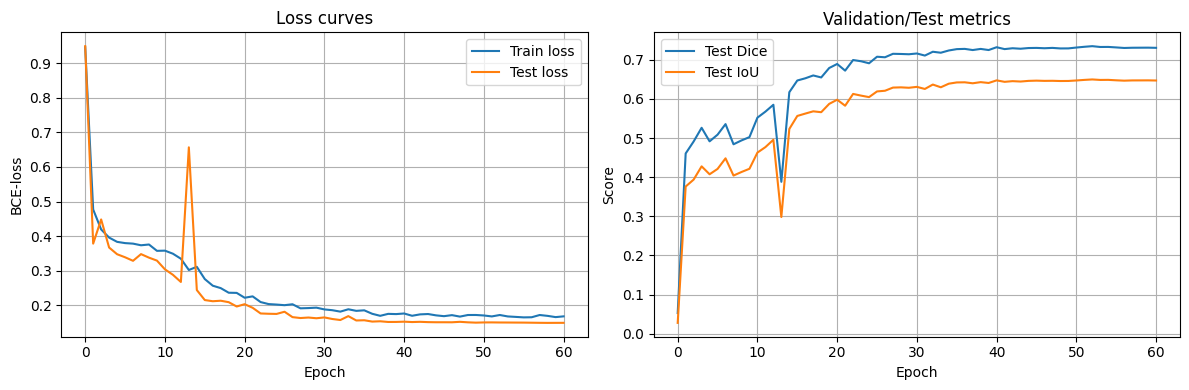

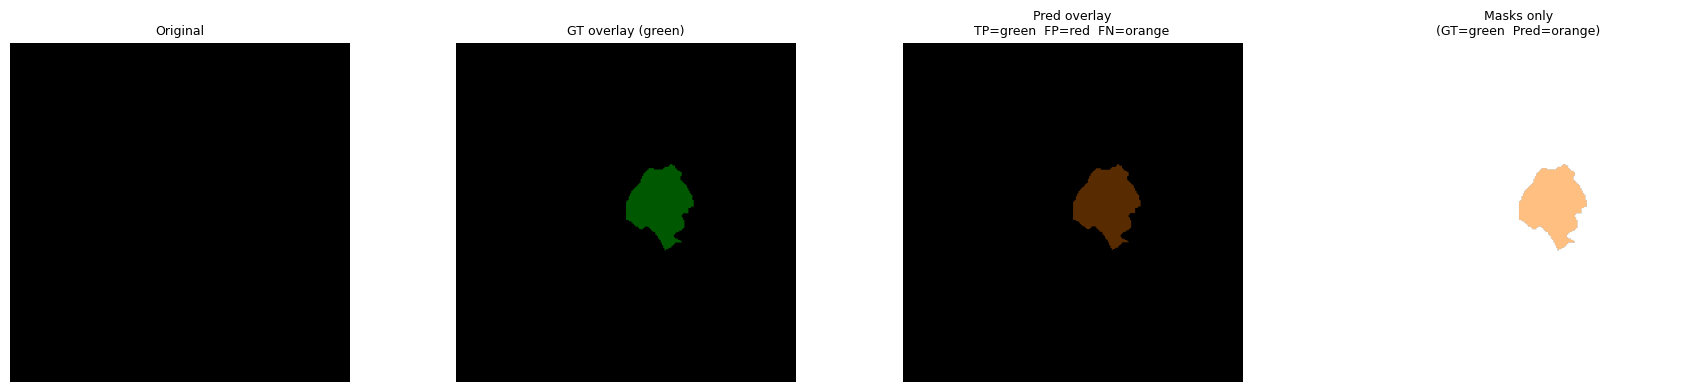

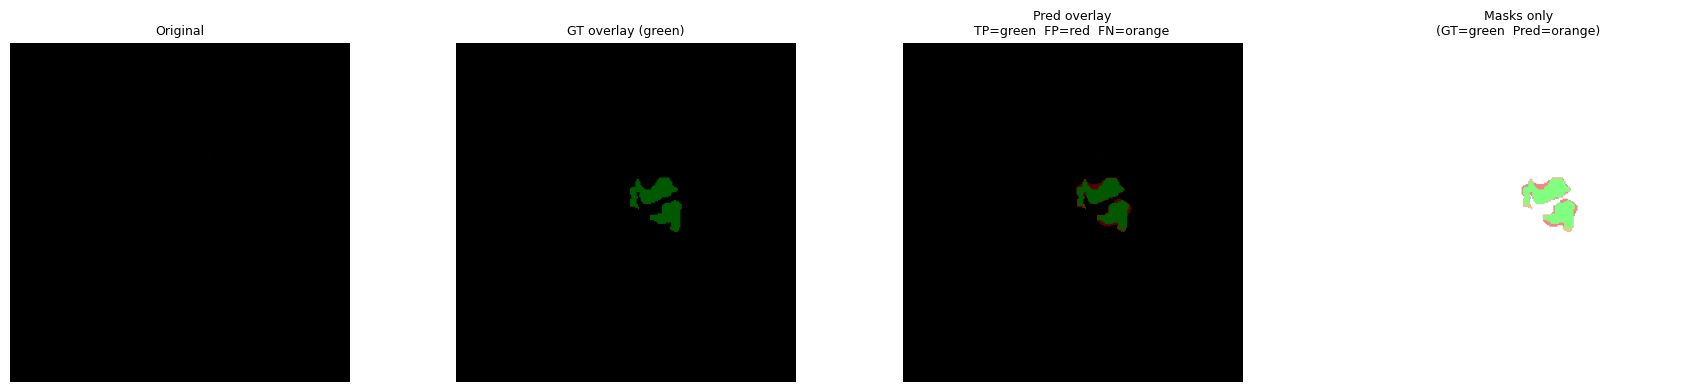

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


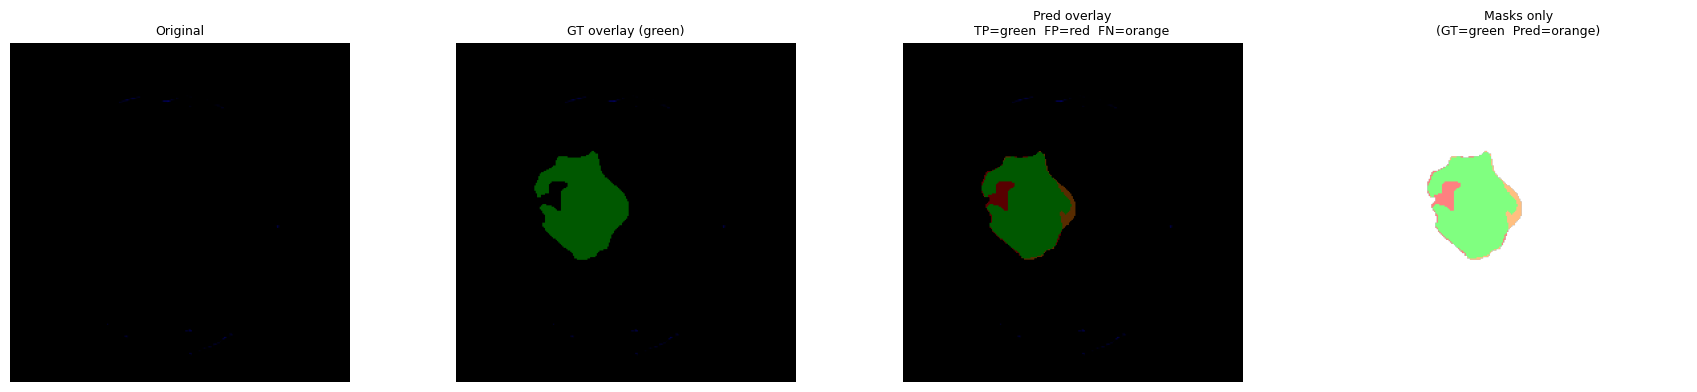

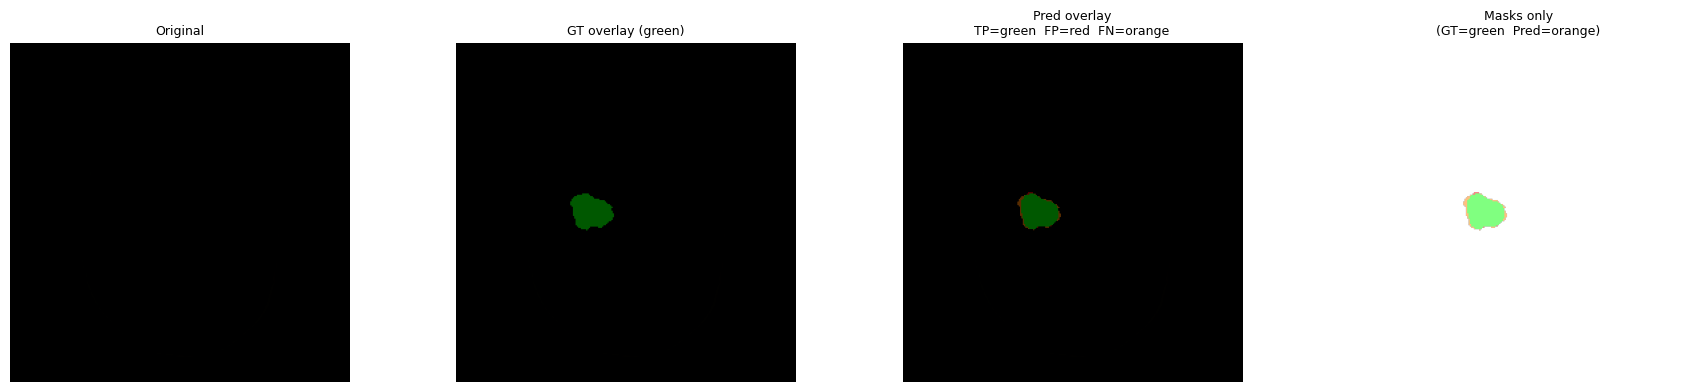

In [14]:
model = BaselineUNet(num_layers=params_aug['num_layers'], num_filters=params_aug['num_filters'])
device = torch.device('cuda')

trained_model, results_tversky_aug = train(
        model,
        train_loader_aug,
        val_loader_aug,
        device,
        lr=params_aug['lr'],
        optimizer_class=optim.Adam if params_aug['optimizer'] == "Adam" else optim.SGD,
        loss_fn=tversky_loss,
        epochs=60,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params_aug['step_size'], "gamma": params_aug['gamma']},
        early_stopping=False
    )   

evaluate(results_tversky_aug)

Final Test Dice: 0.7848
Final Test IoU : 0.6968


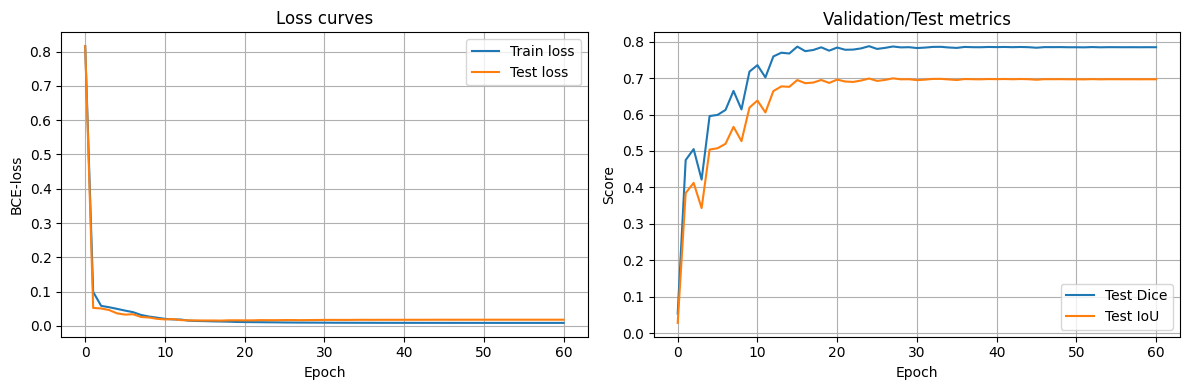

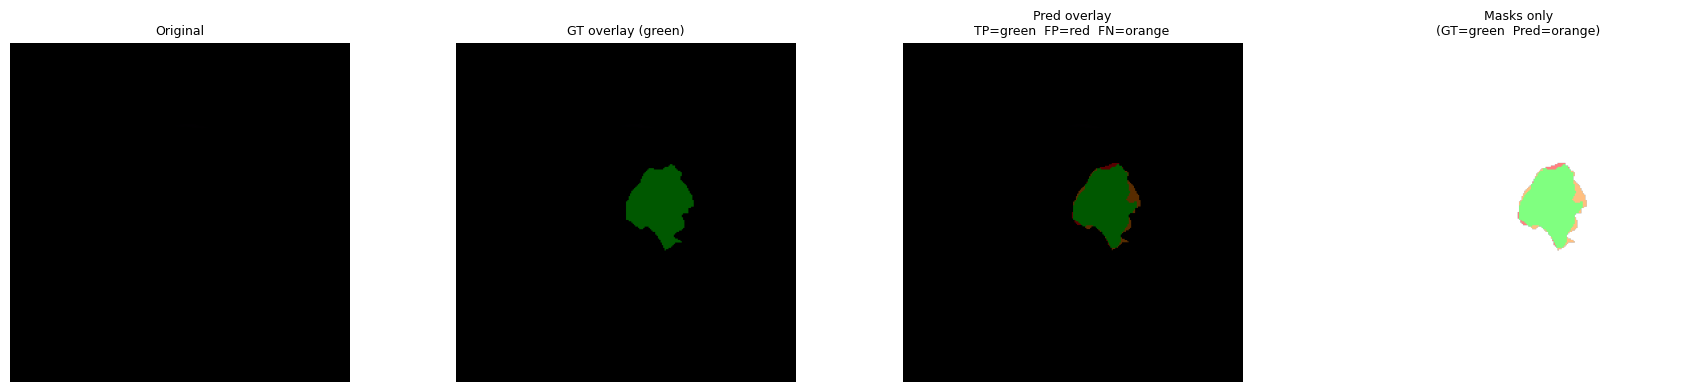

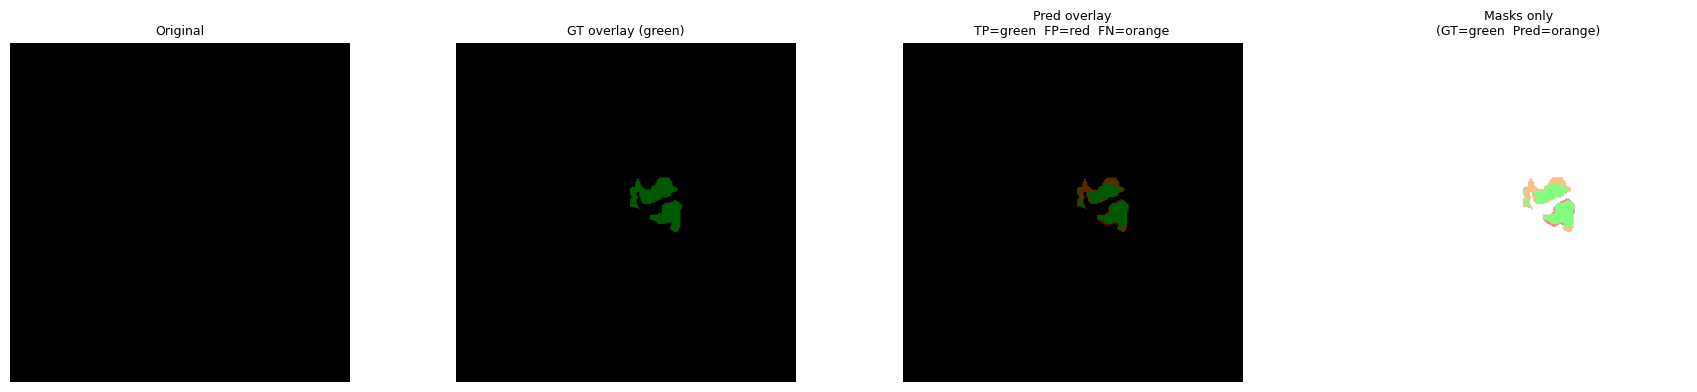

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


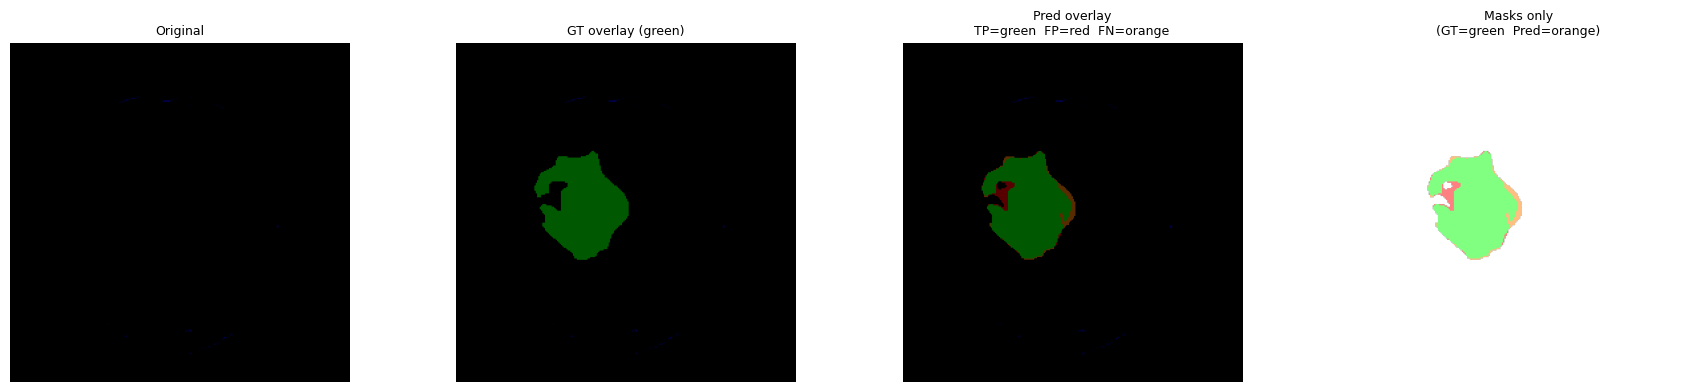

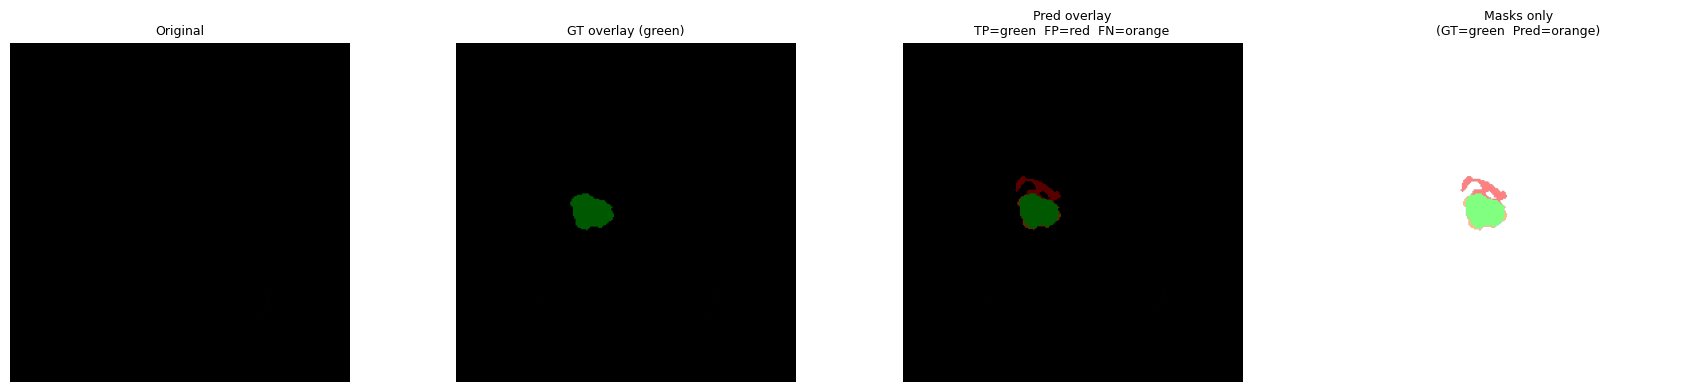

In [16]:
model_noaug = BaselineUNet(num_layers=params_noaug['num_layers'], num_filters=params_noaug['num_filters'])
trained_model_noaug, results_bce_noaug = train(
    model_noaug,
    train_loader_noaug,
    val_loader_noaug,
    device,
    lr=params_noaug['lr'],
    optimizer_class=optim.Adam if params_noaug['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug['step_size'], "gamma": params_noaug['gamma']},
    early_stopping=False
)
evaluate(results_bce_noaug)

Final Test Dice: 0.7913
Final Test IoU : 0.7006


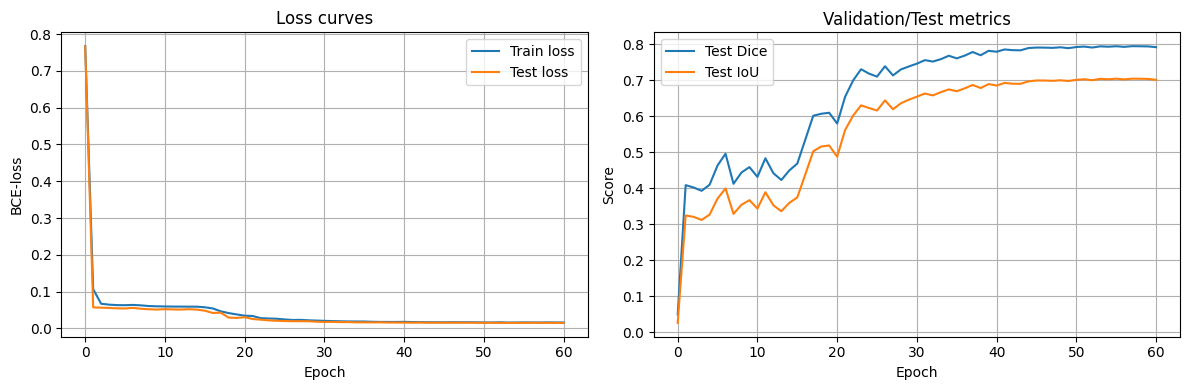

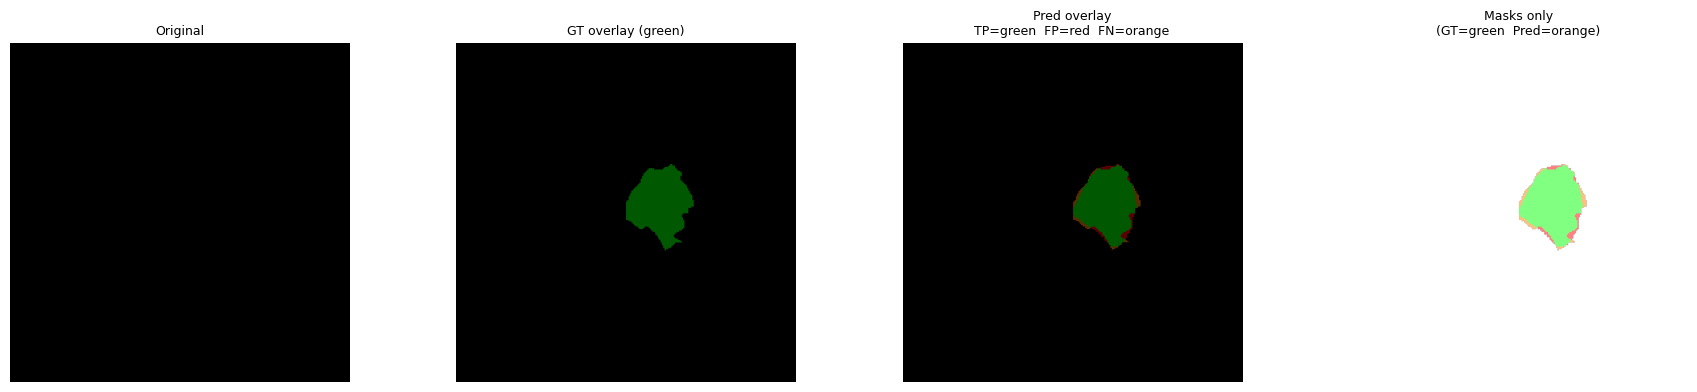

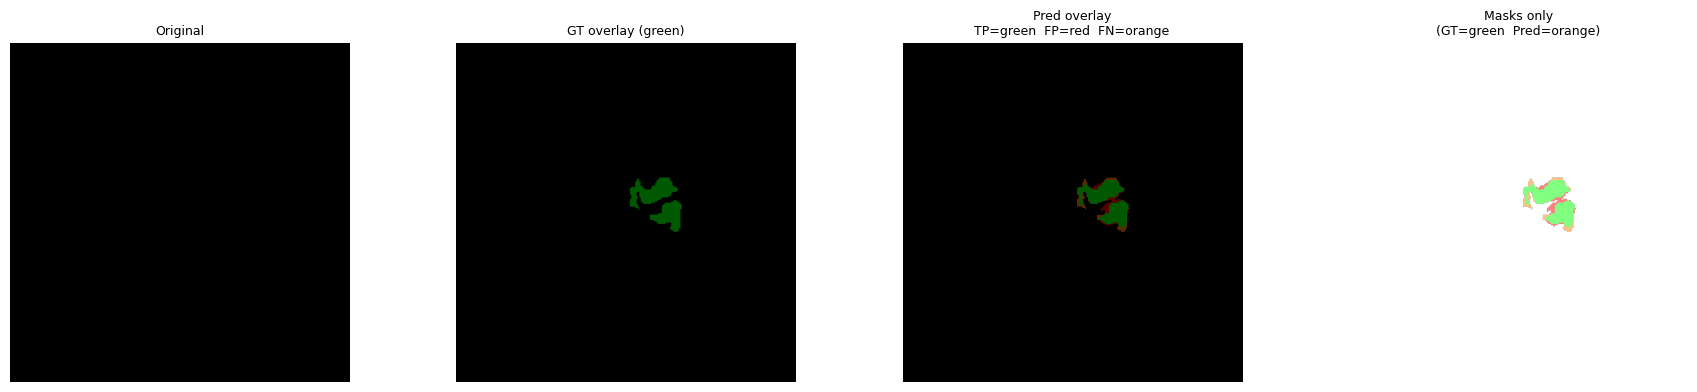

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


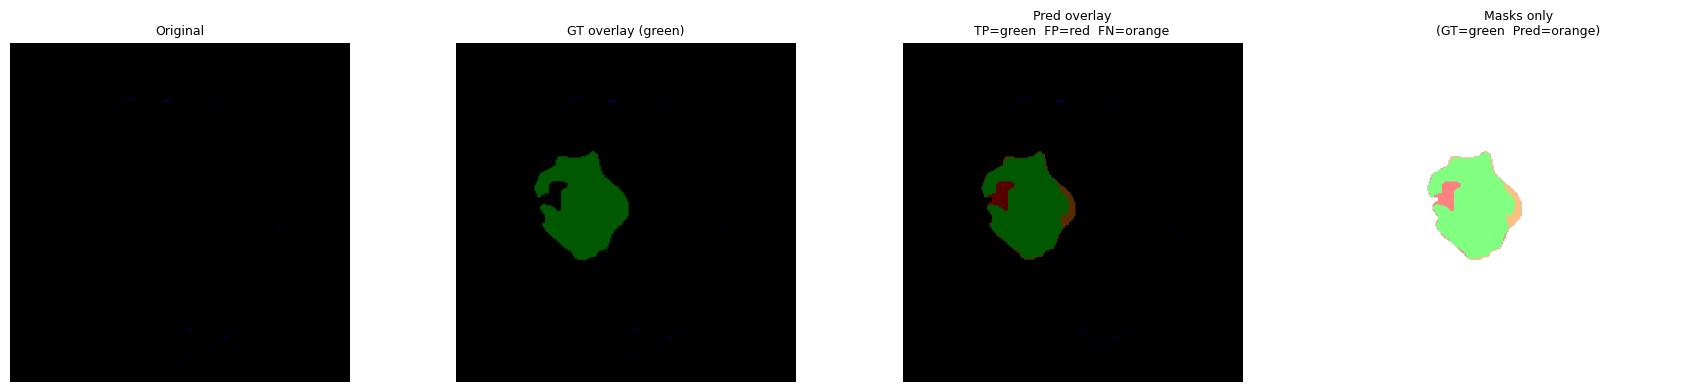

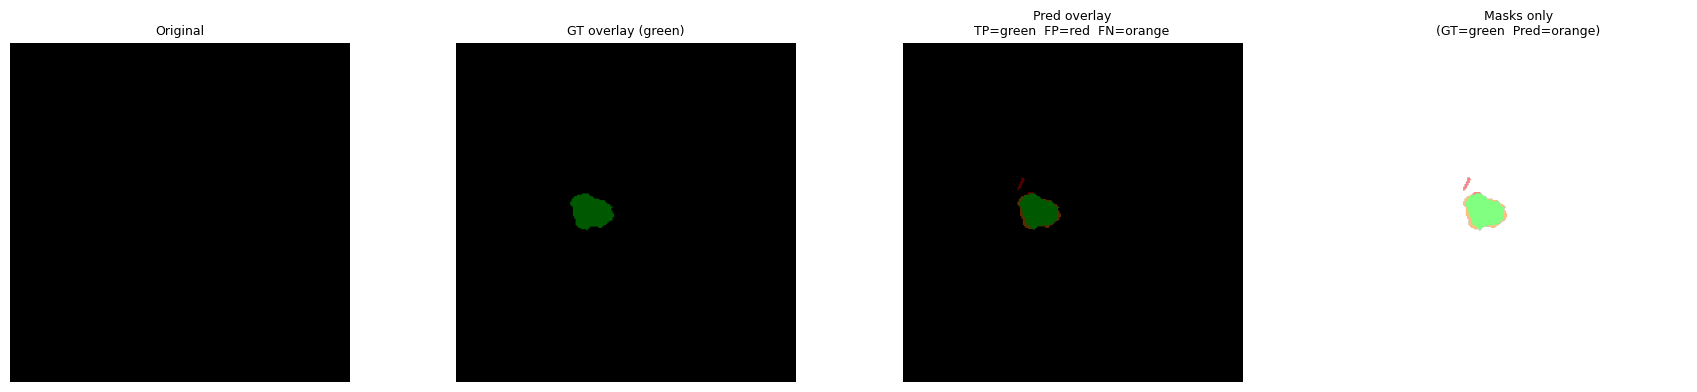

In [17]:
model_aug = BaselineUNet(num_layers=params_aug['num_layers'], num_filters=params_aug['num_filters'])
trained_model_noaug, results_bce_aug = train(
    model_aug,
    train_loader_aug,
    val_loader_aug,
    device,
    lr=params_aug['lr'],
    optimizer_class=optim.Adam if params_aug['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_aug['step_size'], "gamma": params_aug['gamma']},
    early_stopping=False
)
evaluate(results_bce_aug)

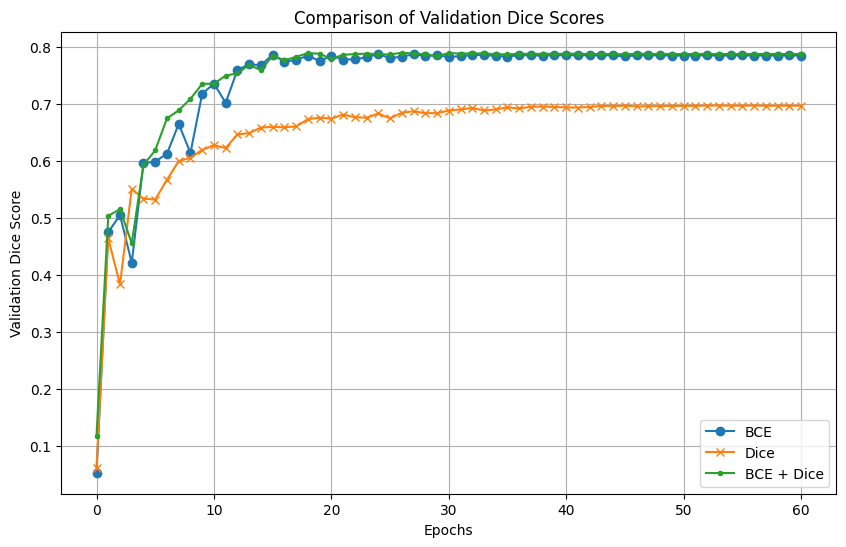

In [26]:
results_list_noaug = [
    results_bce_noaug,
    results_dice_noaug,
    results_bce_dice_noaug,
]
labels_list = [
    "BCE",
    "Dice",
    "BCE + Dice",
]
evaluate_losses(results_list_noaug, labels_list)

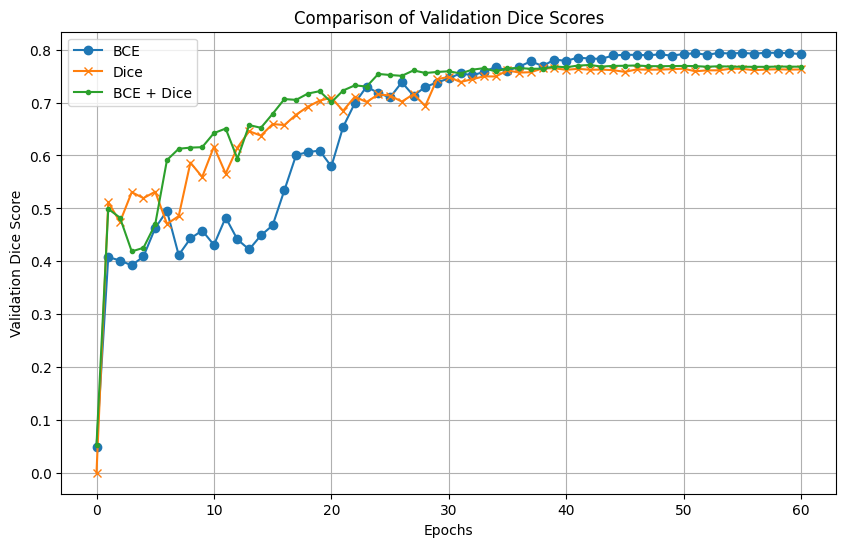

In [27]:
results_list_aug = [
    results_bce_aug,
    results_dice_aug,
    results_bce_dice_aug,
]
evaluate_losses(results_list_aug, labels_list)

Final Test Dice: 0.4719
Final Test IoU : 0.3798


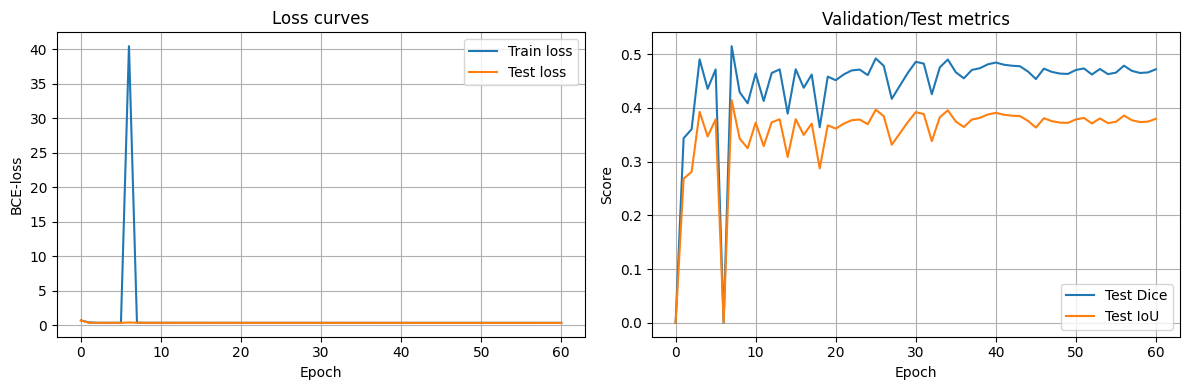

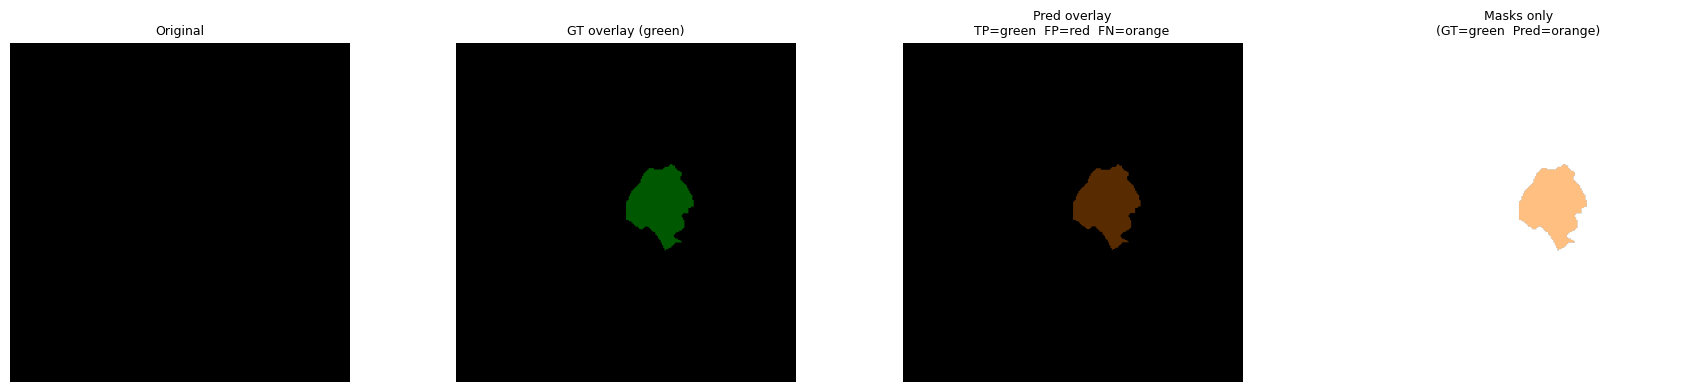

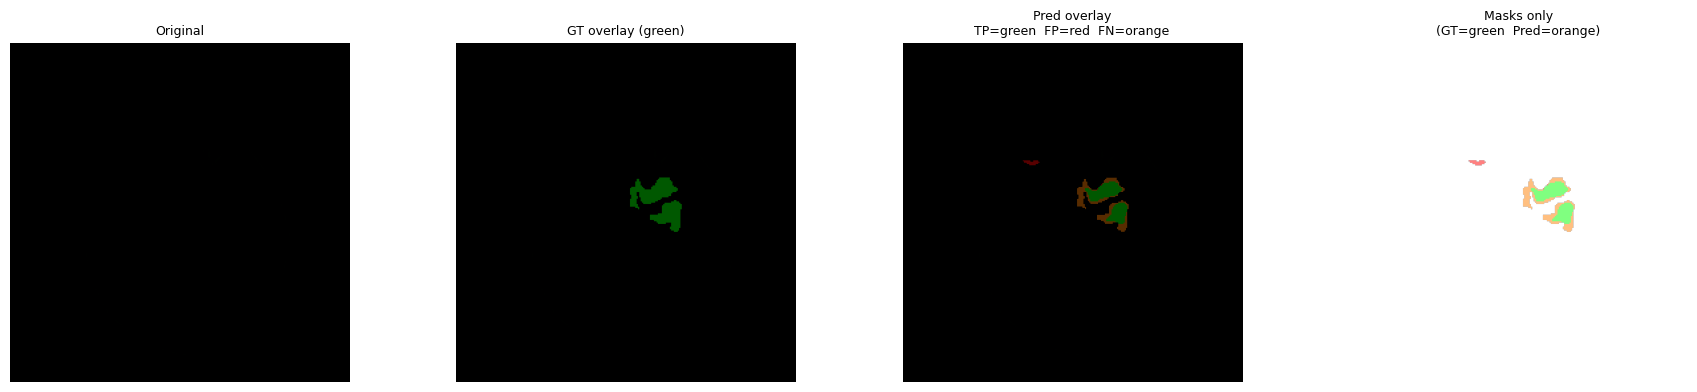

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


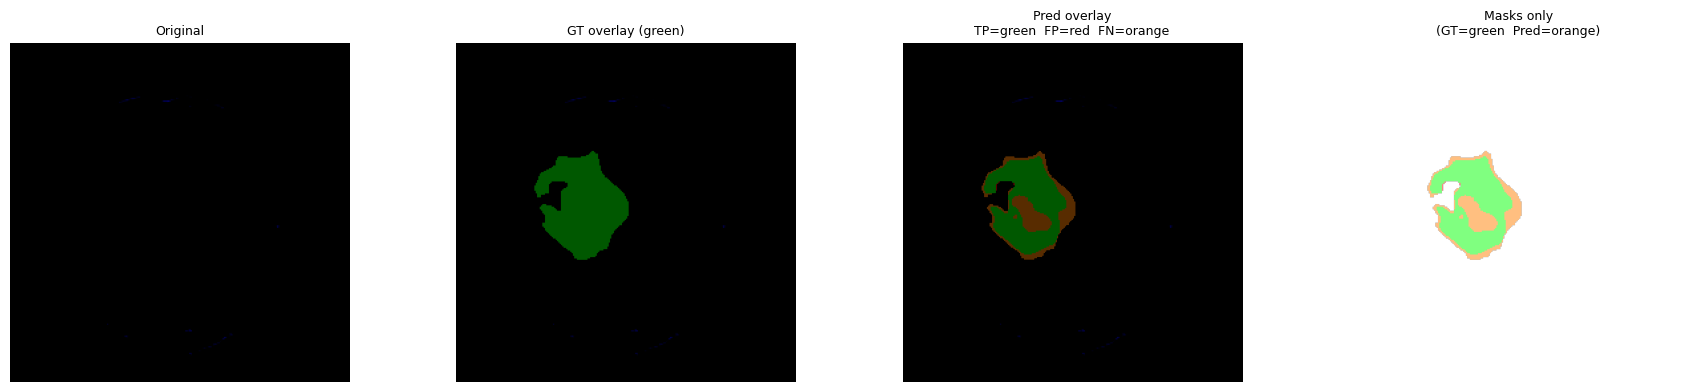

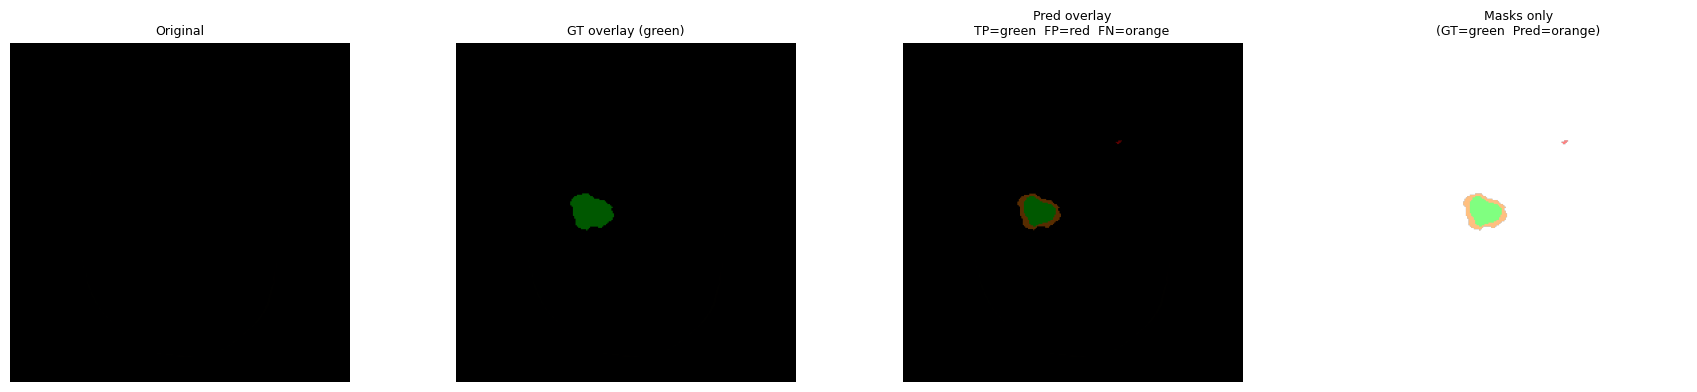

In [ ]:
from train_generalized_earlystopping import train, dice_loss, bce_loss, bce_dice_loss, tversky_loss
from eval import evaluate, evaluate_losses, evaluate_classification
from hyperparameter_search import create_study
from BaselineUNetParams import BaselineUNet
from OriginalUNet import OriginalUNet
import torch.optim as optim
# Compare model with and without augmentation: plot val (CV) and test dice for both

# 1. Run hyperparameter search and training WITH augmentation
#study_aug_original = create_study(n_trials=10, df=df, original_model=True, augment=True)
#params_aug_original = study_aug_original.best_params
#trial_aug_original = study_aug_original.best_trial
#print(f"Best trial with augmentation: {trial_aug_original.number} with value {trial_aug_original.value}")
#train_loader_aug, val_loader_aug = get_dataloaders(df, val_split=0.15, batch_size=params_aug_original["batch_size"], omit_empty_masks=True, augment=True)

model_aug_original = OriginalUNet()
device = torch.device('cuda')
trained_model_aug_original, results_aug_original = train(
    model_aug_original,
    train_loader_aug,
    val_loader_aug,
    device,
    lr=params_aug['lr'],
    optimizer_class=optim.Adam if params_aug['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_aug['step_size'], "gamma": params_aug['gamma']},
    early_stopping=False
)
evaluate(results_aug_original)
#cv_val_dice_aug_original = study_aug_original.best_trial.user_attrs.get("cv_val_dice", None)
#if cv_val_dice_aug_original is not None:
#    results_aug_original["history"]["cv_val_dice"] = cv_val_dice_aug_original

#device = torch.device('cuda')

# 2. Run hyperparameter search and training WITHOUT augmentation
#study_noaug_original = create_study(n_trials=3, df=df, original_model=True, augment=False)
#params_noaug_original = study_noaug_original.best_params
#trial_noaug_original = study_noaug_original.best_trial
#print(f"Best trial without augmentation: {trial_noaug_original.number} with value {trial_noaug_original.value}")

#train_loader_noaug_original, val_loader_noaug_original = get_dataloaders(df, val_split=0.15, batch_size=params_aug_original["batch_size"], omit_empty_masks=True, augment=False)

#cv_val_dice_noaug_original = study_noaug_original.best_trial.user_attrs.get("cv_val_dice", None)
#if cv_val_dice_noaug_original is not None:
#    results_noaug_original["history"]["cv_val_dice"] = cv_val_dice_noaug_original

# 3. Plot val (CV) and test dice for both models
#import matplotlib.pyplot as plt

#epochs_aug_original = range(len(results_aug_original["history"]["val_dice"]))
#epochs_noaug_original = range(len(results_noaug_original["history"]["val_dice"]))

#plt.figure(figsize=(10, 6))
#plt.plot(epochs_aug_original, results_aug_original["history"]["val_dice"], label="Test Dice (Aug)", color="tab:blue")
#if "cv_val_dice" in results_aug_original["history"]:
#    min_len = min(len(epochs_aug_original), len(results_aug_original["history"]["cv_val_dice"]))
#    plt.plot(
#        list(epochs_aug_original)[:min_len],
#        results_aug_original["history"]["cv_val_dice"][:min_len],
#        "--", label="Val Dice (Aug)", color="tab:blue", alpha=0.6
#   )

#plt.plot(epochs_noaug_original, results_noaug_original["history"]["val_dice"], label="Test Dice (No Aug)", color="tab:orange")
#if "cv_val_dice" in results_noaug_original["history"]:
#    min_len = min(len(epochs_noaug_original), len(results_noaug_original["history"]["cv_val_dice"]))
#    plt.plot(
#        list(epochs_noaug_original)[:min_len],
#        results_noaug_original["history"]["cv_val_dice"][:min_len],
#        "--", label="Val Dice (No Aug)", color="tab:orange", alpha=0.6
#    )

#plt.xlabel("Epochs")
#plt.ylabel("Dice Score")
#plt.title("Original UNet: Validation (CV) and Test Dice: With vs Without Augmentation")
#plt.legend()
#plt.grid(True)
#plt.show()

Final Test Dice: 0.7647
Final Test IoU : 0.6706


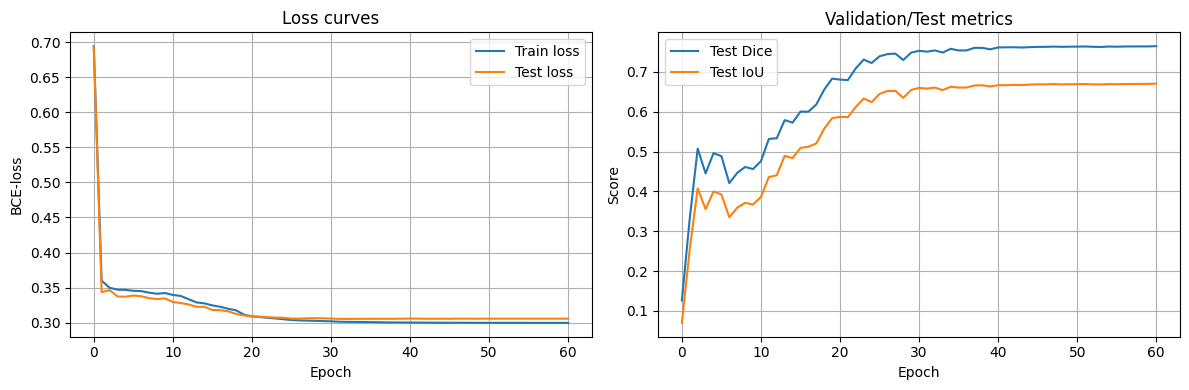

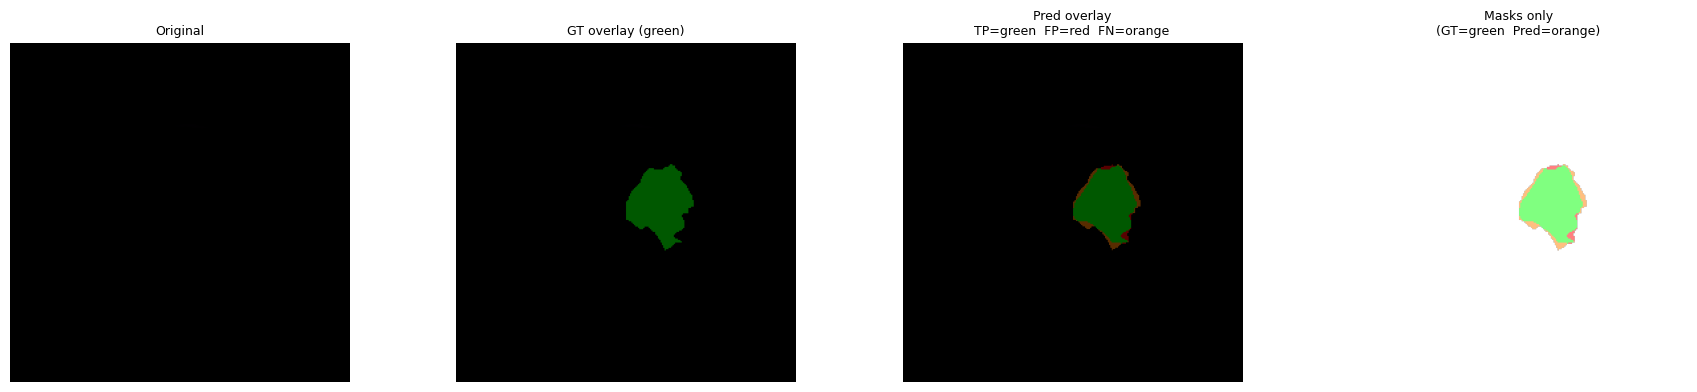

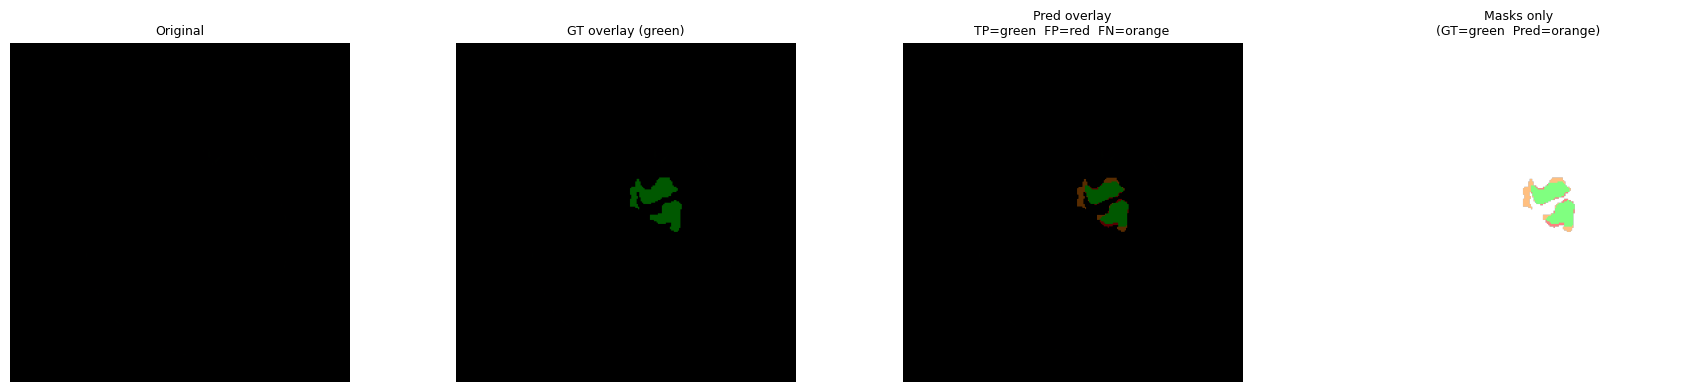

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


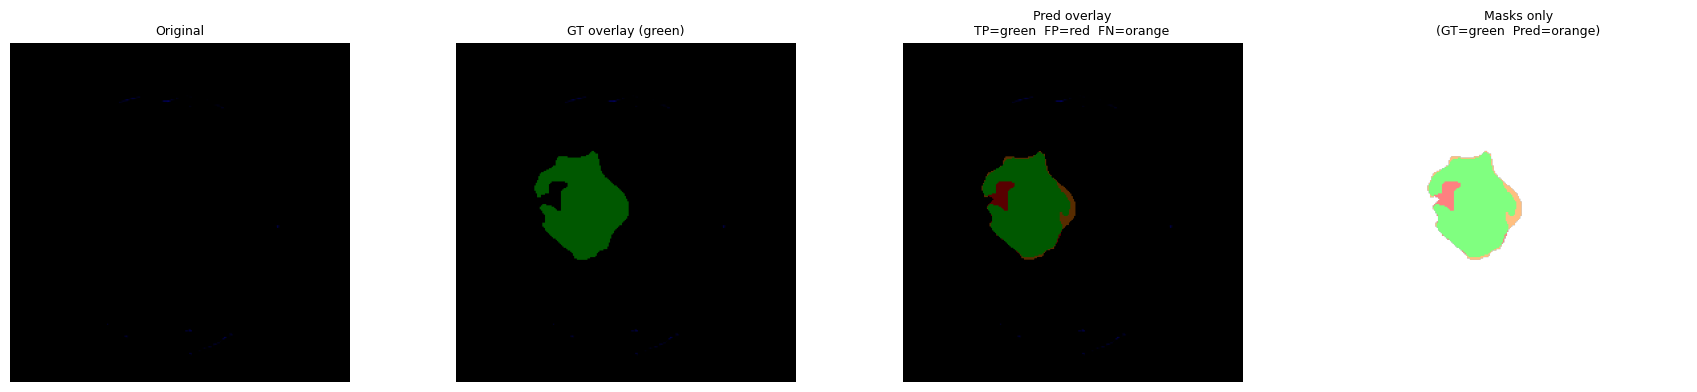

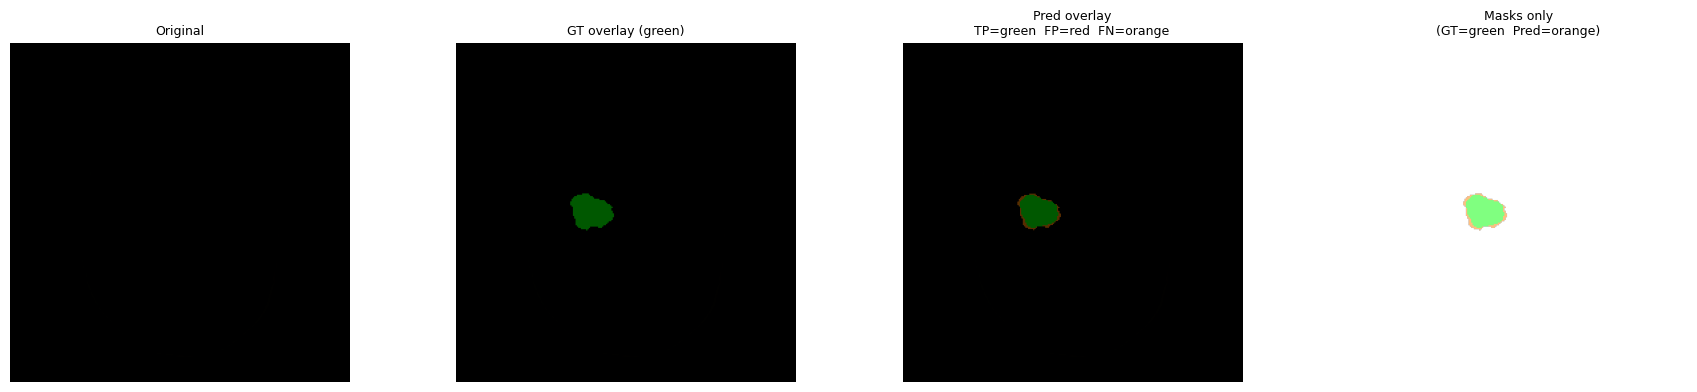

In [29]:
model_noaug_original = OriginalUNet()
trained_model_noaug_original, results_noaug_original = train(
    model_noaug_original,
    train_loader_noaug,
    val_loader_noaug,
    device,
    lr=params_noaug['lr'],
    optimizer_class=optim.Adam if params_noaug['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug['step_size'], "gamma": params_noaug['gamma']},
    early_stopping=False
)
evaluate(results_noaug_original)